# Goal:
The goal of this notebook is to study the convergence of the Mean Variational Error (MVE) vs the number of sequences when the optimization is initialized at a random gate set.

This idea came out after working in the notebook `1q_random_channel_vs_sequences.ipynb`. There, we used the perturbed target initialization. 

The hypothesis is that, to be able to see the phase transition as done in the mGST paper, we need to start far away enough from the target gate set. Besides the reconstruction algorithm, this is basically the only thing missing to have the exact same setup as Fig. 3 in the mGST paper.

If this doesn't work, we would be running out of ideas of why is this phase transition not shown ... so it better work 😳!!!

Date of creation: 04.08.2026

In [307]:
from mGST.utility_functions_comparisons import get_target_operators_gate_set_name, get_compressed_rep_from_mgst_output, kraus_tensor_to_mgst, get_initial_gate_set_for_optimization, get_mgst_tensors_from_psd_representation
from mGST.simulate import apply_noisy_kraus_tensors_to_target_gate_set, get_random_noisy_kraus_tensors_for_gate_set, get_random_gate_set_superop, generate_sequence_indices, run_optimization_workflow, run_optimization_workflow_multi_init, run_optimization_workflow_multi_init_realizations
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.visualization import plot_cost_function, plot_many_mean_std_vs_x
from mGST.analysis import compute_mve_and_wve_for_all_realizations, compute_avg_and_std_along_keys, get_all_realizations_for_key, combine_error_results, save_optimization_result, save_variational_errors
from mGST.gauge_analysis import max_num_parameters, min_num_parameters

import jax.numpy as jnp

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
num_sequences = 100
num_shots = 1000
seq_len_list = [1, 8, 14]
num_qubits = 1
dim = 2 ** num_qubits
state_rank = dim # max
povm_rank = dim # max
kraus_rank = dim**2
num_gates = 3
num_povm = dim
gate_set_name = "1QXYI"
noise_strength = 5e-3

In [356]:
# under these parameter, these are the min an max number of parameters based on gauge considerations.
kraus_rank_test = 4

min_expected, max_expected = min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, state_rank=state_rank, povm_rank=povm_rank, kraus_rank=kraus_rank_test), max_num_parameters(num_qubits=num_qubits, num_gates=num_gates, state_rank=state_rank, povm_rank=povm_rank, kraus_rank=kraus_rank_test)
print(f"Min expected parameters: {min_expected}, Max expected parameters: {max_expected}")

Min expected parameters: 39, Max expected parameters: 103


# Noiseless and noisy tensors

In [8]:
target_operators, gate_labels = get_target_operators_gate_set_name(gate_set_name=gate_set_name)

INFO:2026-08-04 17:25:12,830:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-08-04 17:25:12,830 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-08-04 17:25:12,838:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

In [14]:
random_kraus_tensors = get_random_noisy_kraus_tensors_for_gate_set(
    num_gates=num_gates,
    dim=dim,
    rank_kraus=kraus_rank,
    noise_strength=noise_strength,
    seed=42
)

In [16]:
noisy_gate_set_superop = apply_noisy_kraus_tensors_to_target_gate_set(
    kraus_tensors_noisy=random_kraus_tensors,
    target_gate_set=target_operators,
    is_target_vectorized=True,
)

kraus_tensor_noisy, povm_psd_noisy, state_psd_noisy = get_compressed_rep_from_mgst_output(*noisy_gate_set_superop.values(), kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

In [20]:
# let's get the remaining PSD representations
kraus_target_superop = kraus_tensor_to_mgst(target_operators["kraus"])
# 1. Target
target_gate_set_superops = {
    "kraus": kraus_target_superop,
    "povm": target_operators["povm"],
    "state": target_operators["state"],
}

# 2. Initiallization
init_gate_set_psd = get_initial_gate_set_for_optimization(
    target_superops=target_gate_set_superops,
    kraus_rank=kraus_rank,
    state_rank=state_rank,
    povm_rank=povm_rank
)

init_gate_set_superop = get_mgst_tensors_from_psd_representation(*init_gate_set_psd.values())

# Gathering them all in one place
noisy_gate_set_psd = {
    "kraus": kraus_tensor_noisy,
    "povm": povm_psd_noisy,
    "state": state_psd_noisy,
}

# Optimization

In [229]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.
relative_precision = 1e-11 # decrease by 2 orders of magnitude.
global_gradient_norm_tol = 1e-10 #

tr_schedule_silence = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=False, verbose_cg=False, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))


optimization_schedule_silence= {
    "kraus": tr_schedule_silence,
    "povm": tr_schedule_silence,
    "state": tr_schedule_silence
}

optimization_options_silence = {
    "schedule": optimization_schedule_silence,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
}
optimization_options_silence

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10,

In [153]:
optimization_schedule_silence["kraus"].items

[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]

In [60]:
optimization_options_random = optimization_options_silence.copy()
optimization_options_random["num_iterations_outer"] = 30

## Warm-up: 
run a simple optimization with random initialization vs target init.

In [46]:
seeds = [42, 43, 44]
rndm_gate_set_superop = get_random_gate_set_superop(num_gates=num_gates, dim=dim, kraus_rank=kraus_rank, num_povm=dim, seeds=seeds)
rndm_gate_set_psd = get_compressed_rep_from_mgst_output(*rndm_gate_set_superop.values(), kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)
rndm_gate_set_psd_dict = {
    "kraus": rndm_gate_set_psd[0],
    "povm": rndm_gate_set_psd[1],
    "state": rndm_gate_set_psd[2],
}

In [35]:
# to make it fair we use the same indices_dict for both optimizations
indices_dict_fixed = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences, seq_len_list=seq_len_list)

### Optimization

In [37]:
opt_result_target_init = run_optimization_workflow(
    num_shots=num_shots,
    init_operators=init_gate_set_psd,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    use_exact_probabilities=False,
    optimization_options=optimization_options_silence,
    warmup_run=False,
    use_log_likelihood=True,
    compute_least_squares=1, # to compute after every operator
    optimization_verbose=False, # we trust it (?)
    indices_dict=indices_dict_fixed
    )

Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 5.104362e+04. |r∇f(x)|: 1.011573e-03. Radius: 1.56e-03. Re

In [47]:
opt_result_rndm_init = run_optimization_workflow(
    num_shots=num_shots,
    init_operators=rndm_gate_set_psd_dict,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    use_exact_probabilities=False,
    optimization_options=optimization_options_silence,
    warmup_run=False,
    use_log_likelihood=True,
    compute_least_squares=1, # to compute after every operator
    optimization_verbose=False, # we trust it (?)
    indices_dict=indices_dict_fixed
    )

Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.913667e+04. |r∇f(x)|: 1.579098e+03. Radius: 1.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.829668e+04. |r∇f(x)|: 2.433319e+03. Radius: 2.00e-01. Rejections: 1
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.817560e+04. |r∇f(x)|: 1.671000e-03. Radius: 5.00e-02. Rejections: 1
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.799540e+04. |r∇f(x)|: 2.836987e+00. Radius: 2.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.682901e+04. |r∇f(x)|: 4.787050e+03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: state 🚀.
Optimization finishe

In [71]:
random_inits = 3

opt_results_random_inits = []
for idx in range(random_inits):
    print(f"*** Running optimization with random initialization {idx+1}/{random_inits} ***")
    opt_result_idx = run_optimization_workflow(
        num_shots=num_shots,
        init_operators=None, # random initialization
        operators_psd_true=noisy_gate_set_psd,
        target_superops=target_gate_set_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options_silence,
        warmup_run=False,
        use_log_likelihood=True,
        compute_least_squares=1, # to compute after every operator
        optimization_verbose=False, # we trust it (?)
        indices_dict=indices_dict_fixed
    )
    opt_results_random_inits.append(opt_result_idx)

*** Running optimization with random initialization 1/3 ***
🎲 Generating random initial operators ...
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.891163e+04. |r∇f(x)|: 1.092064e+03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.713222e+04. |r∇f(x)|: 4.488510e+03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.614903e+04. |r∇f(x)|: 4.320566e+00. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.581451e+04. |r∇f(x)|: 4.447368e+00. Radius: 2.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.133495e+04. |r∇f(x)|: 

### Visualization

In [340]:
optimization_results_init = [opt_result_target_init, opt_result_rndm_init] + opt_results_random_inits

title_init = rf"{num_qubits}Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Random Noisy Gate Set | Shots: {num_shots}"

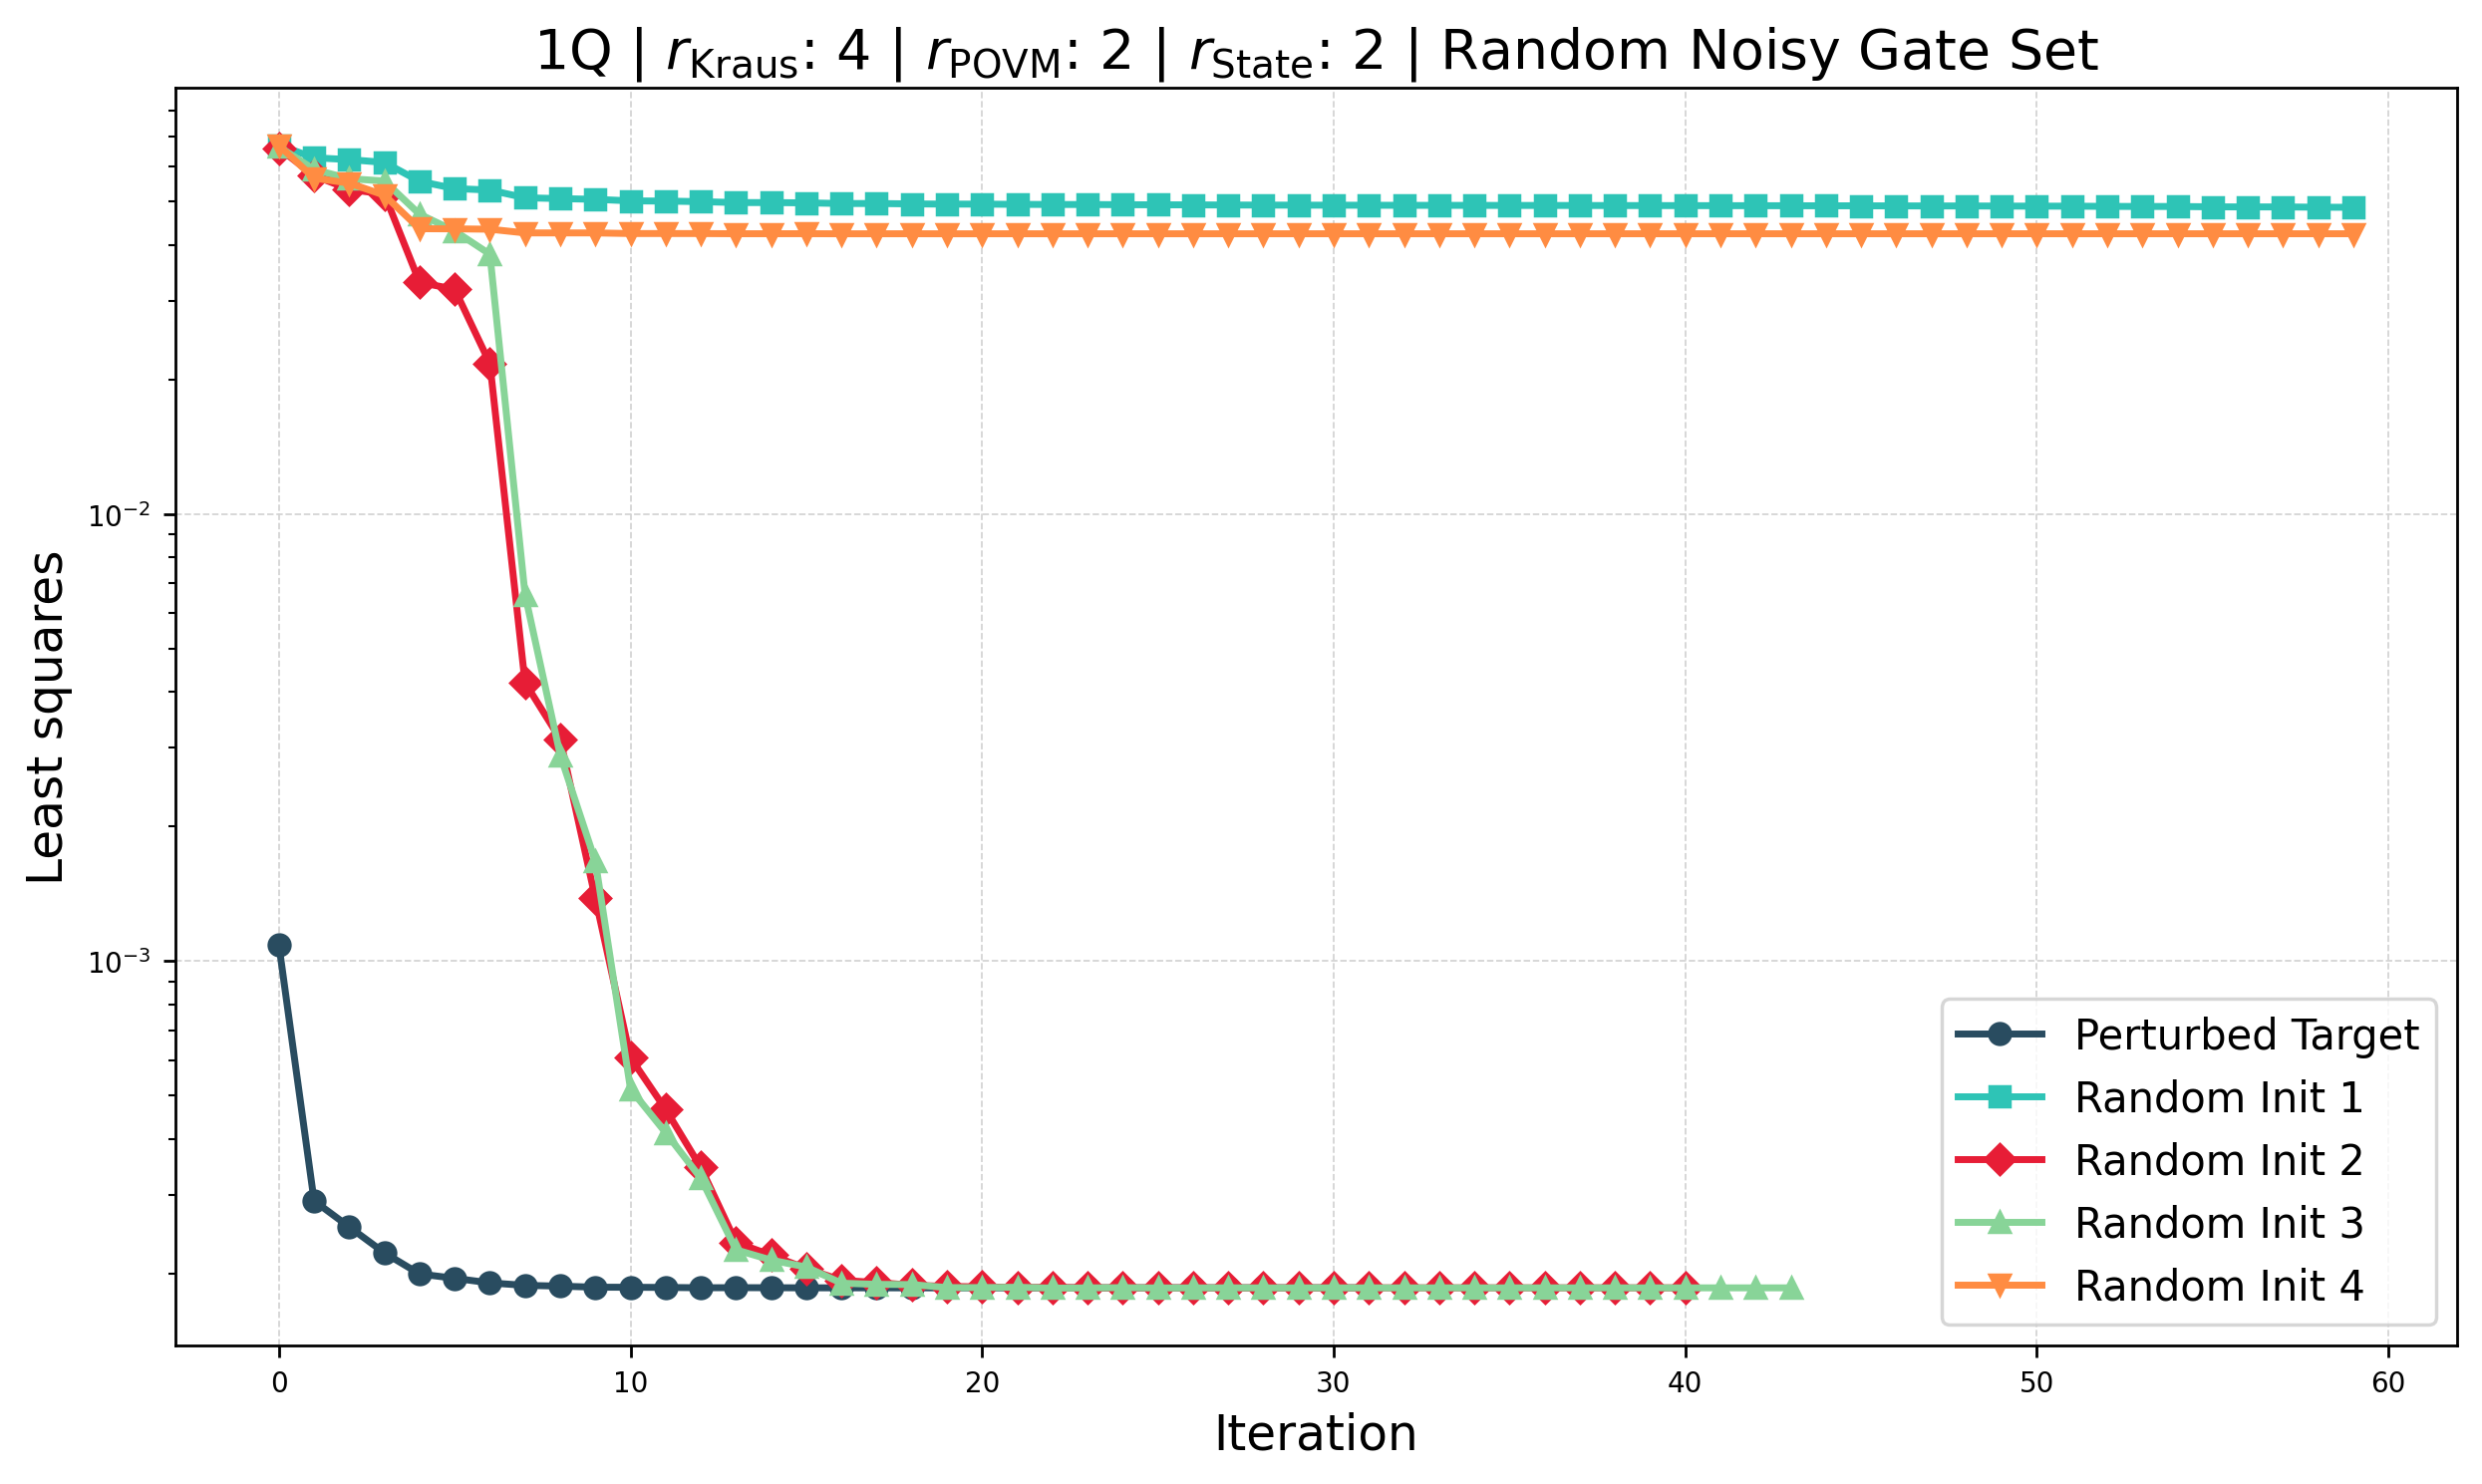

In [78]:
cost_fn_inits = [res["cost_fn_history"]["least_squares"] for res in optimization_results_init]

labels_init = ["Perturbed Target"] + [f"Random Init {i+1}" for i in range(random_inits+1)]

plot_cost_function(cost_fn_inits[:], title=title_init, labels=labels_init[:], ylabel="Least squares")

In [ ]:
[cost[-1] for cost in cost_fn_inits]

[Array(0.00018554, dtype=float64),
 Array(0.0485346, dtype=float64),
 Array(0.00018554, dtype=float64),
 Array(0.00018554, dtype=float64),
 Array(0.0423497, dtype=float64)]

## Testing for different number of sequences

In [75]:
indices_dict_10_seq = generate_sequence_indices(num_gates=num_gates, num_circuits=10, seq_len_list=seq_len_list)

random_inits_small = 10
opt_results_random_inits_10_seq = []

### optimization

In [76]:
for idx in range(random_inits_small):
    print(f"*** Running optimization with random initialization {idx+1}/{random_inits_small} ***")
    opt_result_idx = run_optimization_workflow(
        num_shots=num_shots,
        init_operators=None, # random initialization
        operators_psd_true=noisy_gate_set_psd,
        target_superops=target_gate_set_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options_silence,
        warmup_run=False,
        use_log_likelihood=True,
        compute_least_squares=1, # to compute after every operator
        optimization_verbose=False, # we trust it (?)
        indices_dict=indices_dict_10_seq, 
    )
    opt_results_random_inits_10_seq.append(opt_result_idx)

*** Running optimization with random initialization 1/10 ***
🎲 Generating random initial operators ...
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.685269e+03. |r∇f(x)|: 5.182576e+02. Radius: 2.00e-01. Rejections: 1
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.423265e+03. |r∇f(x)|: 4.858727e+02. Radius: 4.00e-01. Rejections: 1
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 5.866011e+03. |r∇f(x)|: 1.480078e-03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 5.834248e+03. |r∇f(x)|: 1.587056e-01. Radius: 2.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 5.627910e+03. |r∇f(x)|:

In [83]:
indices_dict_20_seq = generate_sequence_indices(num_gates=num_gates, num_circuits=20, seq_len_list=seq_len_list)
opt_results_random_inits_20_seq = []

for idx in range(random_inits_small):
    print(f"*** Running optimization with random initialization {idx+1}/{random_inits_small} ***")
    opt_result_idx = run_optimization_workflow(
        num_shots=num_shots,
        init_operators=None, # random initialization
        operators_psd_true=noisy_gate_set_psd,
        target_superops=target_gate_set_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options_silence,
        warmup_run=False,
        use_log_likelihood=True,
        compute_least_squares=1, # to compute after every operator
        optimization_verbose=False, # we trust it (?)
        indices_dict=indices_dict_20_seq, 
    )
    opt_results_random_inits_20_seq.append(opt_result_idx)

*** Running optimization with random initialization 1/10 ***
🎲 Generating random initial operators ...
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
at iteration 1 the new count changed to: 11
at iteration 2 the new count changed to: 12
at iteration 3 the new count changed to: 13
at iteration 5 the new count changed to: 14
at iteration 10 the new count changed to: 15
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.368225e+04. |r∇f(x)|: 3.707656e+02. Radius: 2.00e-01. Rejections: 1
at iteration 1 the new count changed to: 11
at iteration 2 the new count changed to: 12
at iteration 3 the new count changed to: 13
at iteration 5 the new count changed to: 14
at iteration 10 the new count changed to: 15
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.225485e+04. |r∇f(x)|: 1.2

In [85]:
indices_dict_30_seq = generate_sequence_indices(num_gates=num_gates, num_circuits=30, seq_len_list=seq_len_list)
opt_results_random_inits_30_seq = []

for idx in range(random_inits_small):
    print(f"*** Running optimization with random initialization {idx+1}/{random_inits_small} ***")
    opt_result_idx = run_optimization_workflow(
        num_shots=num_shots,
        init_operators=None, # random initialization
        operators_psd_true=noisy_gate_set_psd,
        target_superops=target_gate_set_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options_silence,
        warmup_run=False,
        use_log_likelihood=True,
        compute_least_squares=1, # to compute after every operator
        optimization_verbose=False, # we trust it (?)
        indices_dict=indices_dict_30_seq, 
    )
    opt_results_random_inits_30_seq.append(opt_result_idx)

*** Running optimization with random initialization 1/10 ***
🎲 Generating random initial operators ...
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.046845e+04. |r∇f(x)|: 6.265974e+02. Radius: 8.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.845802e+04. |r∇f(x)|: 3.662910e+03. Radius: 2.00e-01. Rejections: 1
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.762884e+04. |r∇f(x)|: 1.930614e-01. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.750825e+04. |r∇f(x)|: 9.409135e+01. Radius: 5.00e-02. Rejections: 1
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 1.618488e+04. |r∇f(x)|:

In [93]:
indices_dict_40_seq = generate_sequence_indices(num_gates=num_gates, num_circuits=40, seq_len_list=seq_len_list)
opt_results_random_inits_40_seq = []

for idx in range(random_inits_small):
    print(f"*** Running optimization with random initialization {idx+1}/{random_inits_small} ***")
    opt_result_idx = run_optimization_workflow(
        num_shots=num_shots,
        init_operators=None, # random initialization
        operators_psd_true=noisy_gate_set_psd,
        target_superops=target_gate_set_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options_silence,
        warmup_run=False,
        use_log_likelihood=True,
        compute_least_squares=1, # to compute after every operator
        optimization_verbose=False, # we trust it (?)
        indices_dict=indices_dict_40_seq, 
    )
    opt_results_random_inits_40_seq.append(opt_result_idx)

*** Running optimization with random initialization 1/10 ***
🎲 Generating random initial operators ...
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.735814e+04. |r∇f(x)|: 1.543787e+03. Radius: 2.00e-01. Rejections: 1
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.616375e+04. |r∇f(x)|: 1.719919e+03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.467450e+04. |r∇f(x)|: 4.314963e-01. Radius: 8.00e-01. Rejections: 0
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.442264e+04. |r∇f(x)|: 1.976600e-02. Radius: 2.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 2.287193e+04. |r∇f(x)|:

### Visualization

In [89]:
labels_init_small_seq = [f"Random Init {i}" for i in range(random_inits_small)]

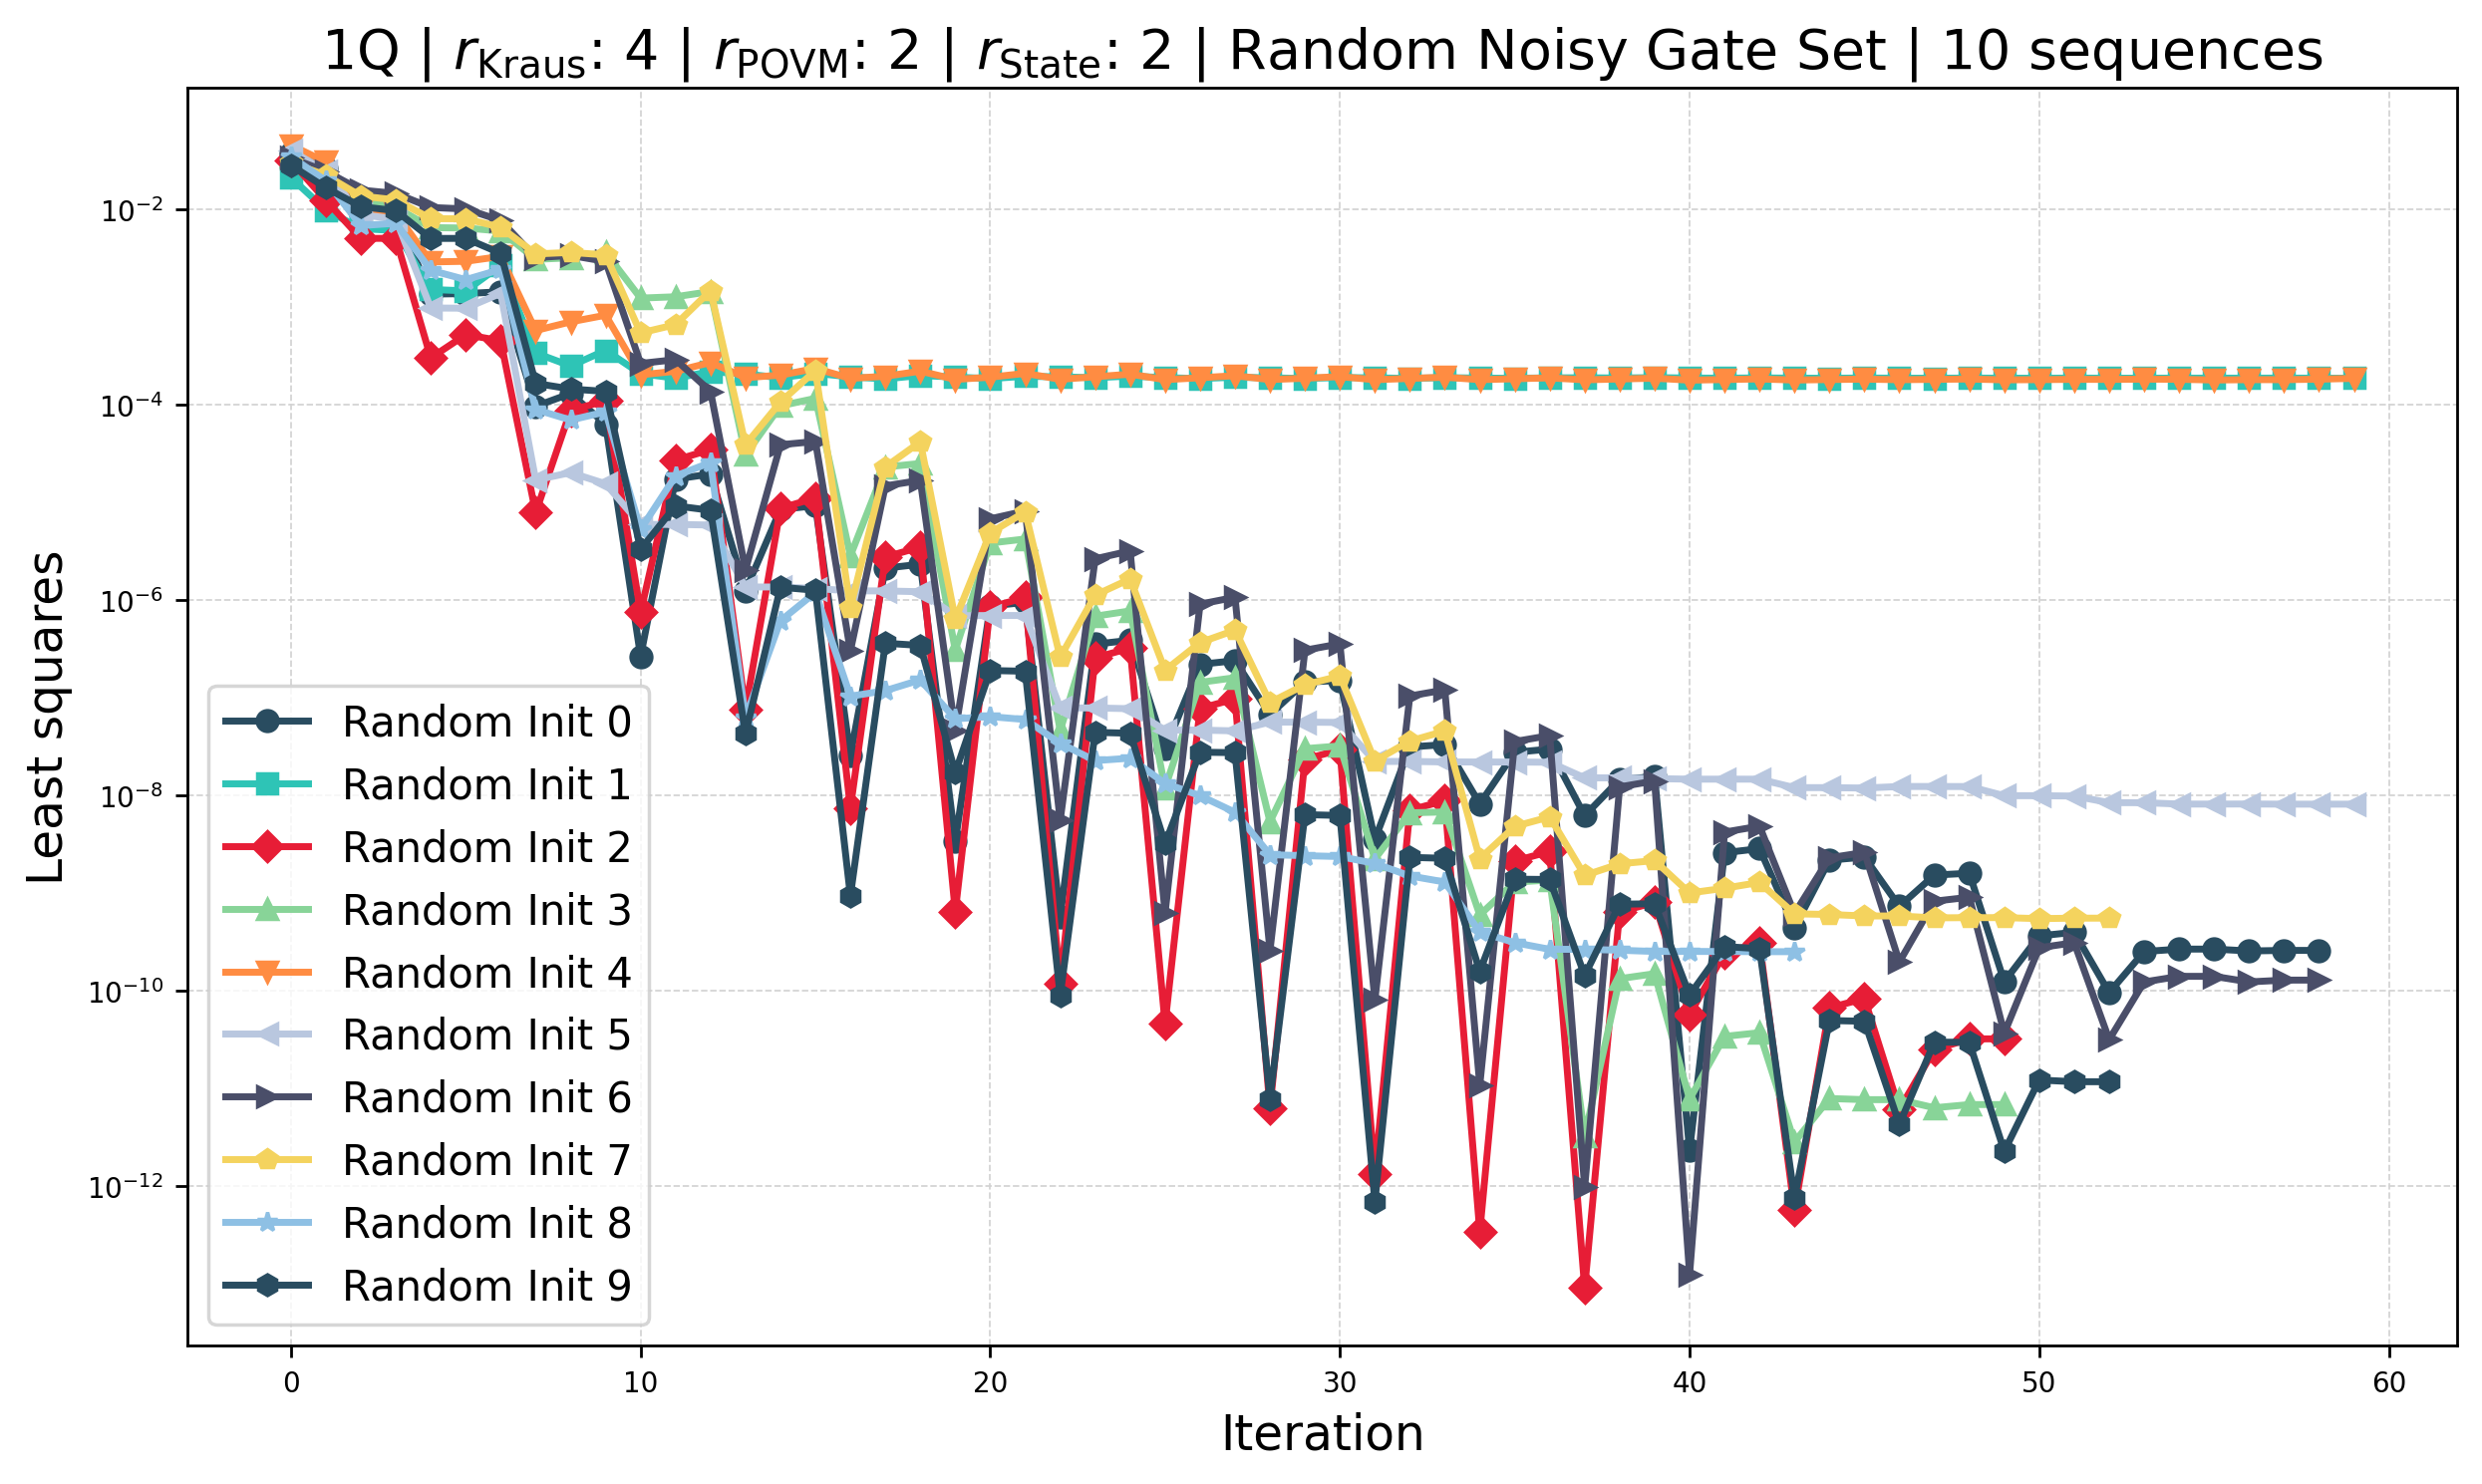

In [90]:
cost_fn_inits_10_seq = [res["cost_fn_history"]["least_squares"] for res in opt_results_random_inits_10_seq]

plot_cost_function(cost_fn_inits_10_seq[:], title=title_init + " | 10 sequences", labels=labels_init_small_seq[:], ylabel="Least squares")

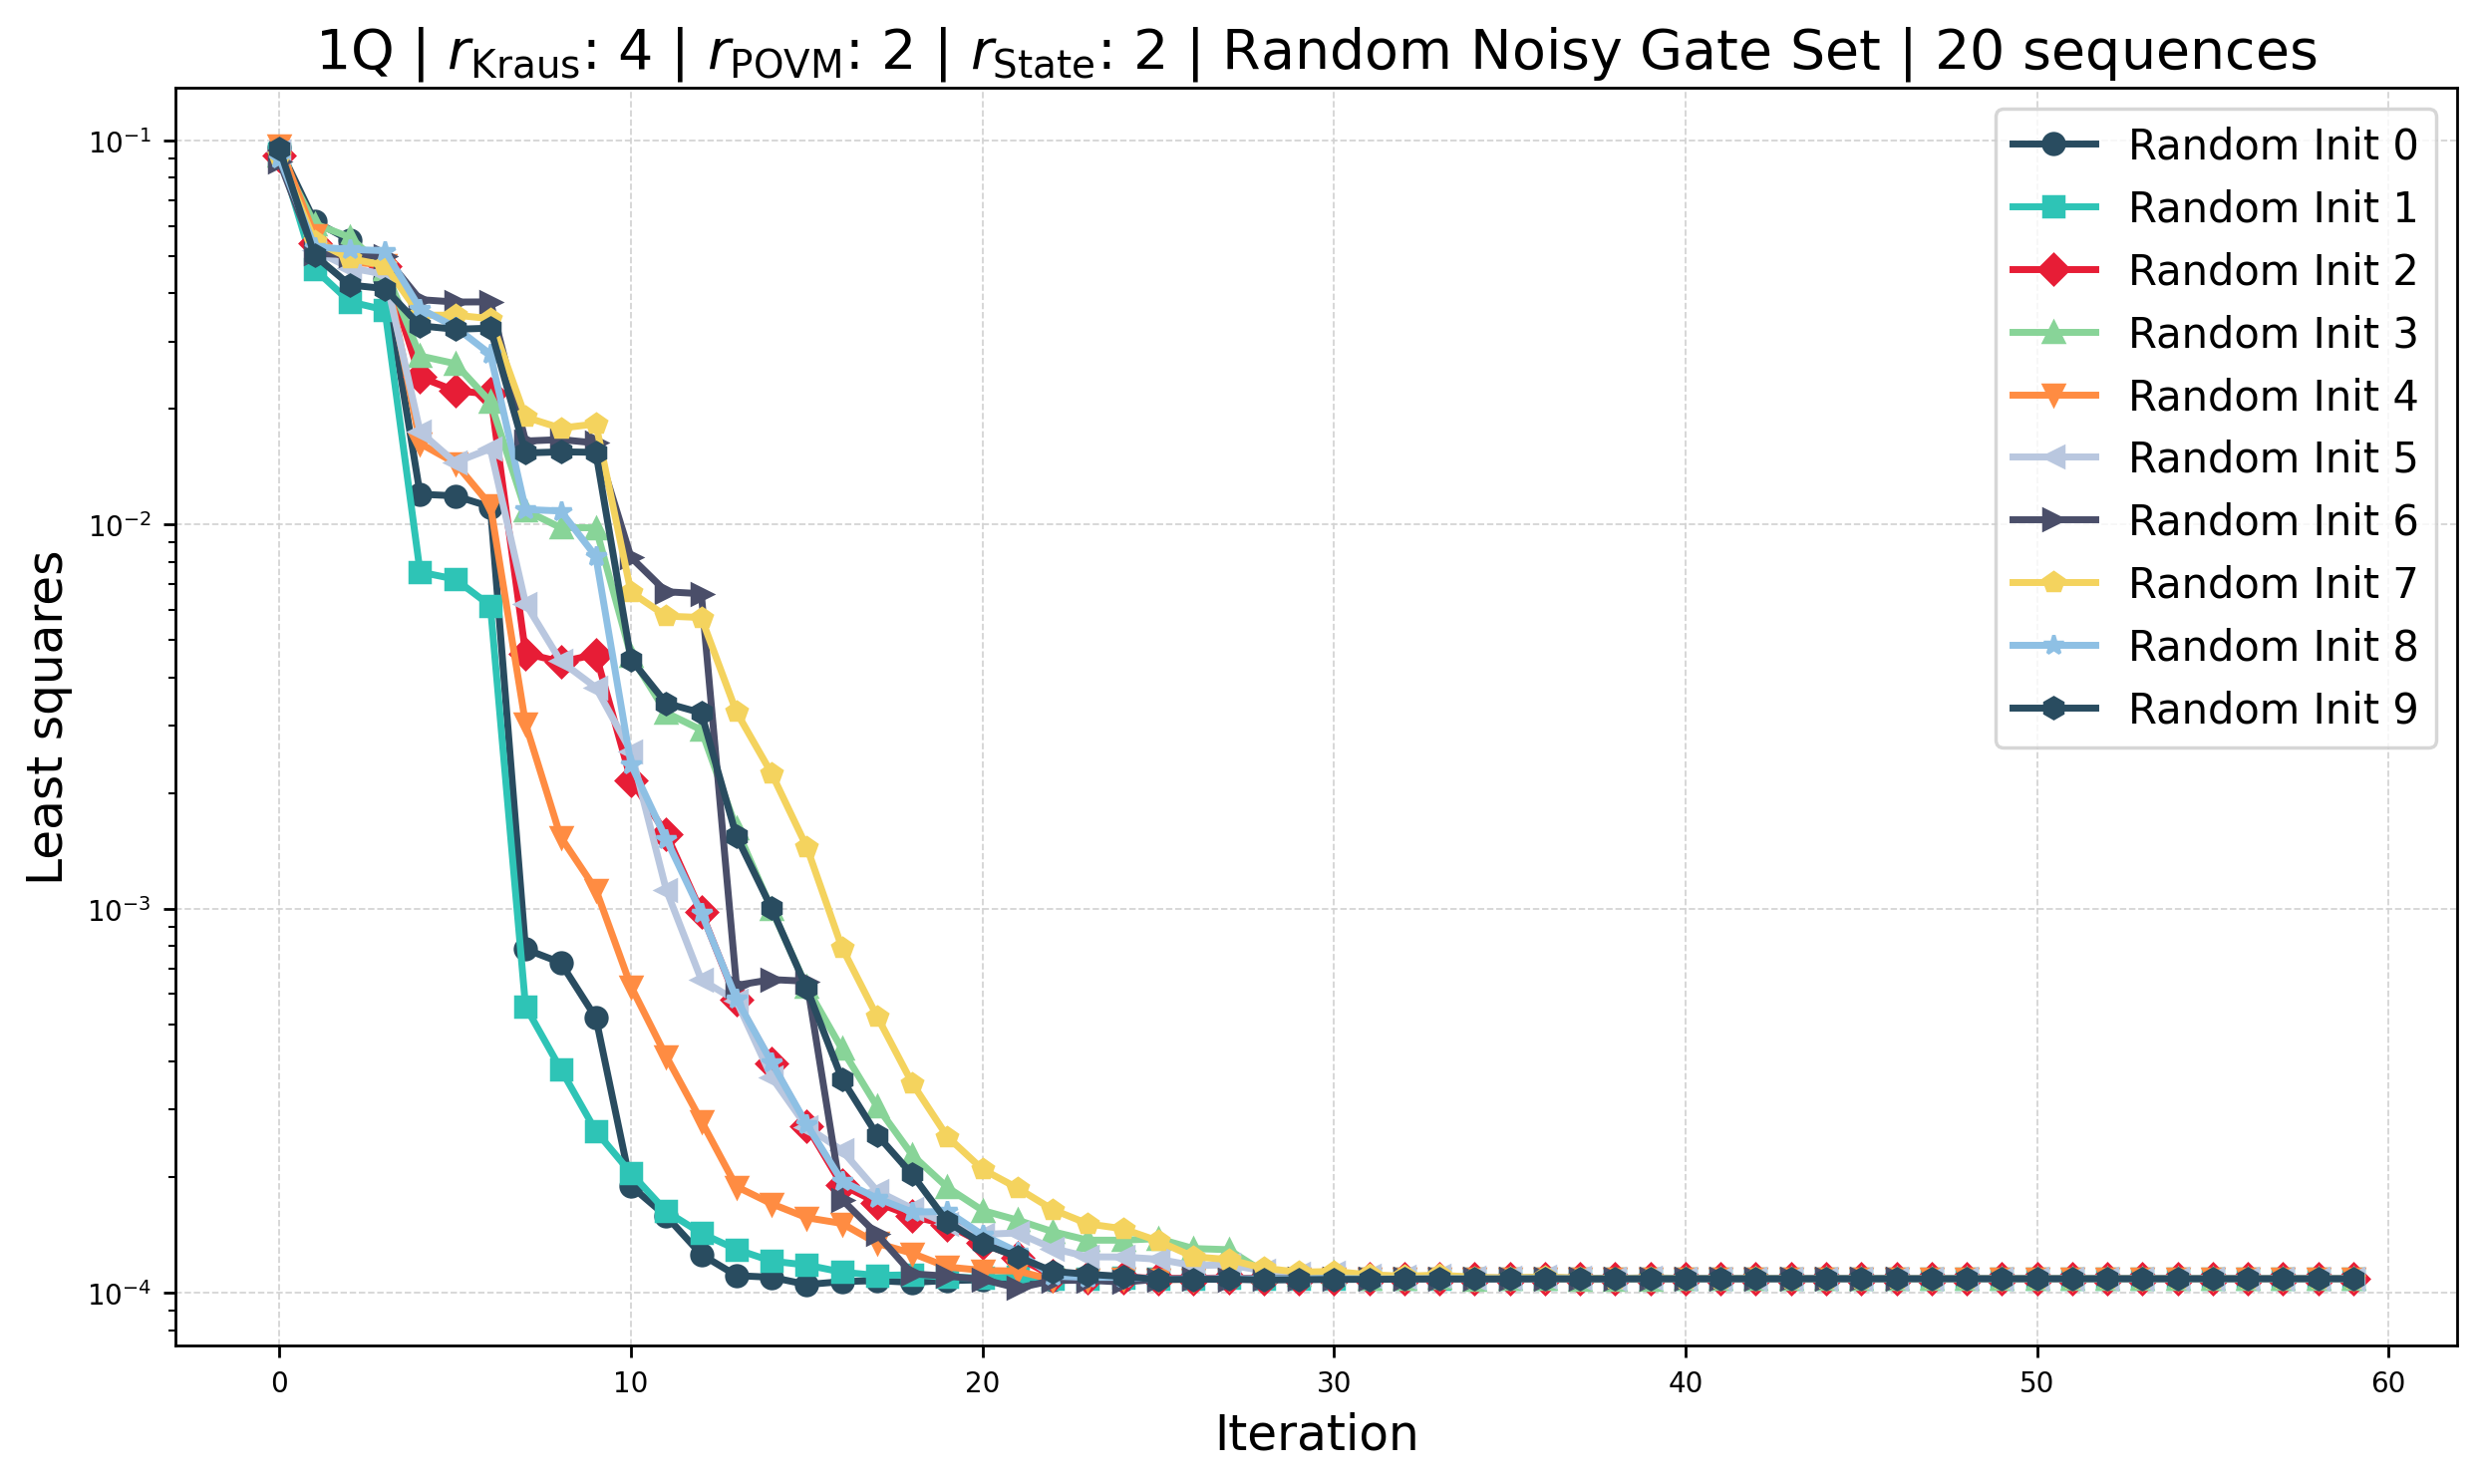

In [91]:
cost_fn_inits_20_seq = [res["cost_fn_history"]["least_squares"] for res in opt_results_random_inits_20_seq]

plot_cost_function(cost_fn_inits_20_seq[:], title=title_init + " | 20 sequences", labels=labels_init_small_seq[:], ylabel="Least squares")

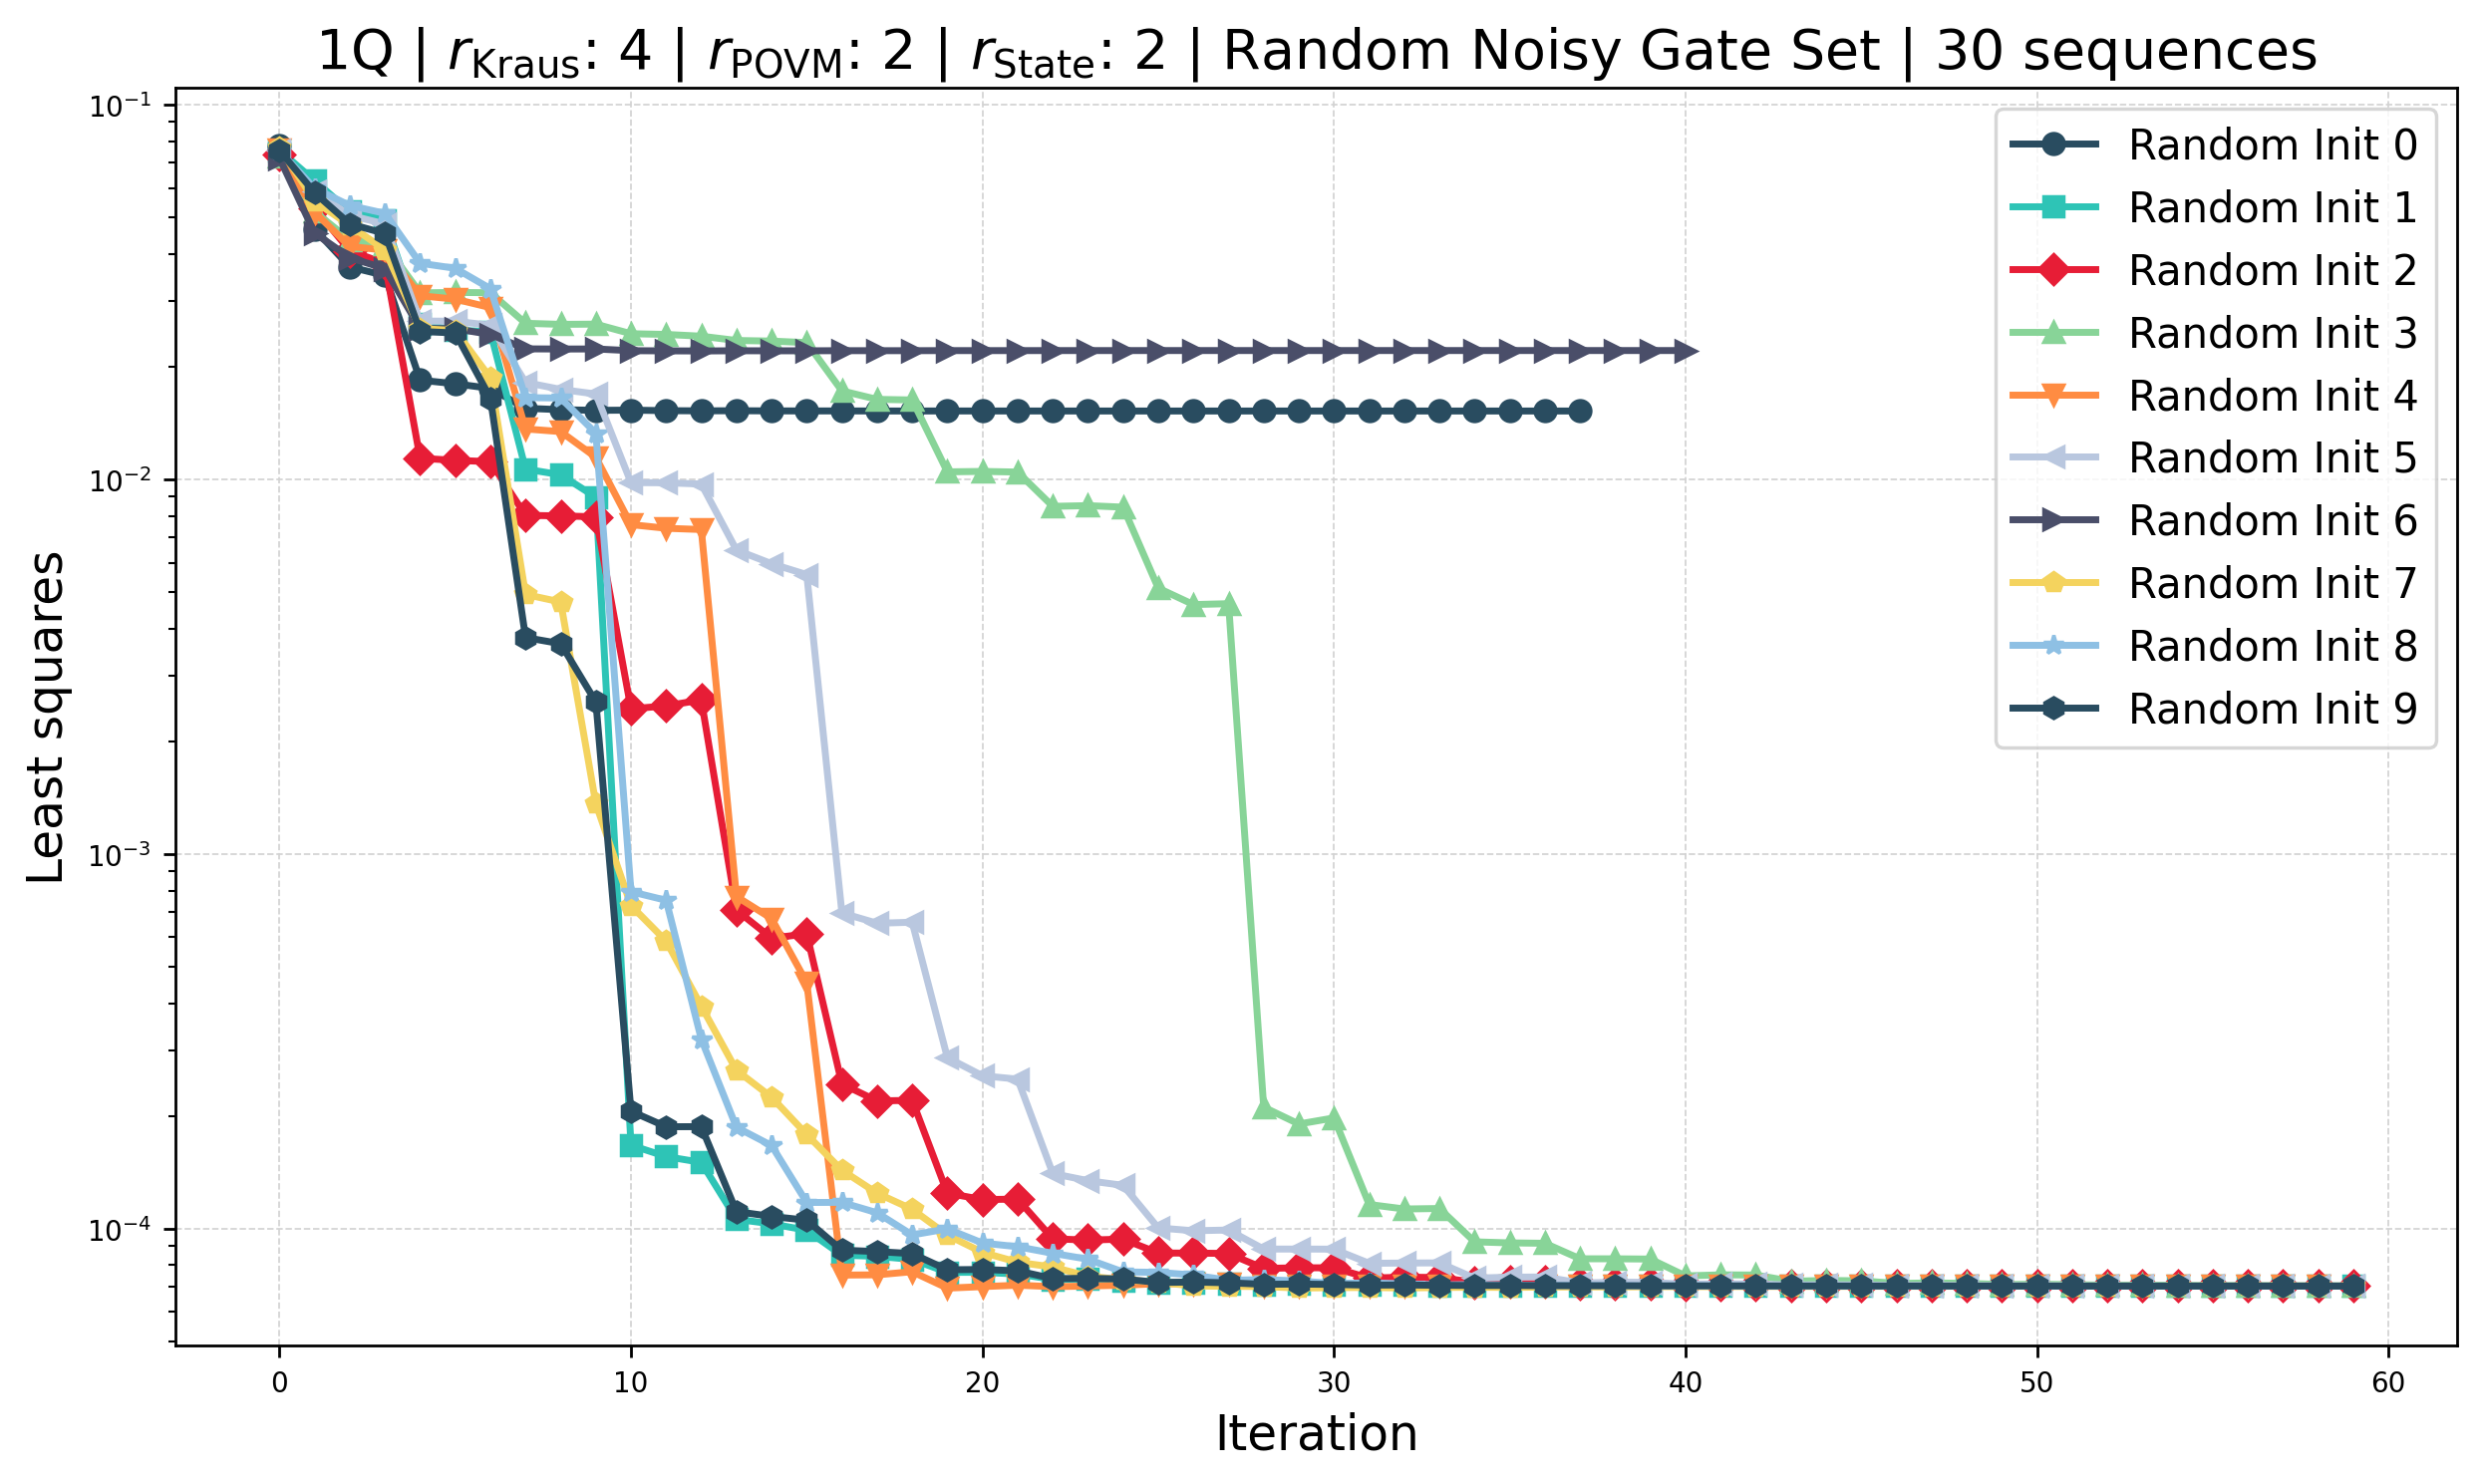

In [92]:
cost_fn_inits_30_seq = [res["cost_fn_history"]["least_squares"] for res in opt_results_random_inits_30_seq]

plot_cost_function(cost_fn_inits_30_seq[:], title=title_init + " | 30 sequences", labels=labels_init_small_seq[:], ylabel="Least squares")

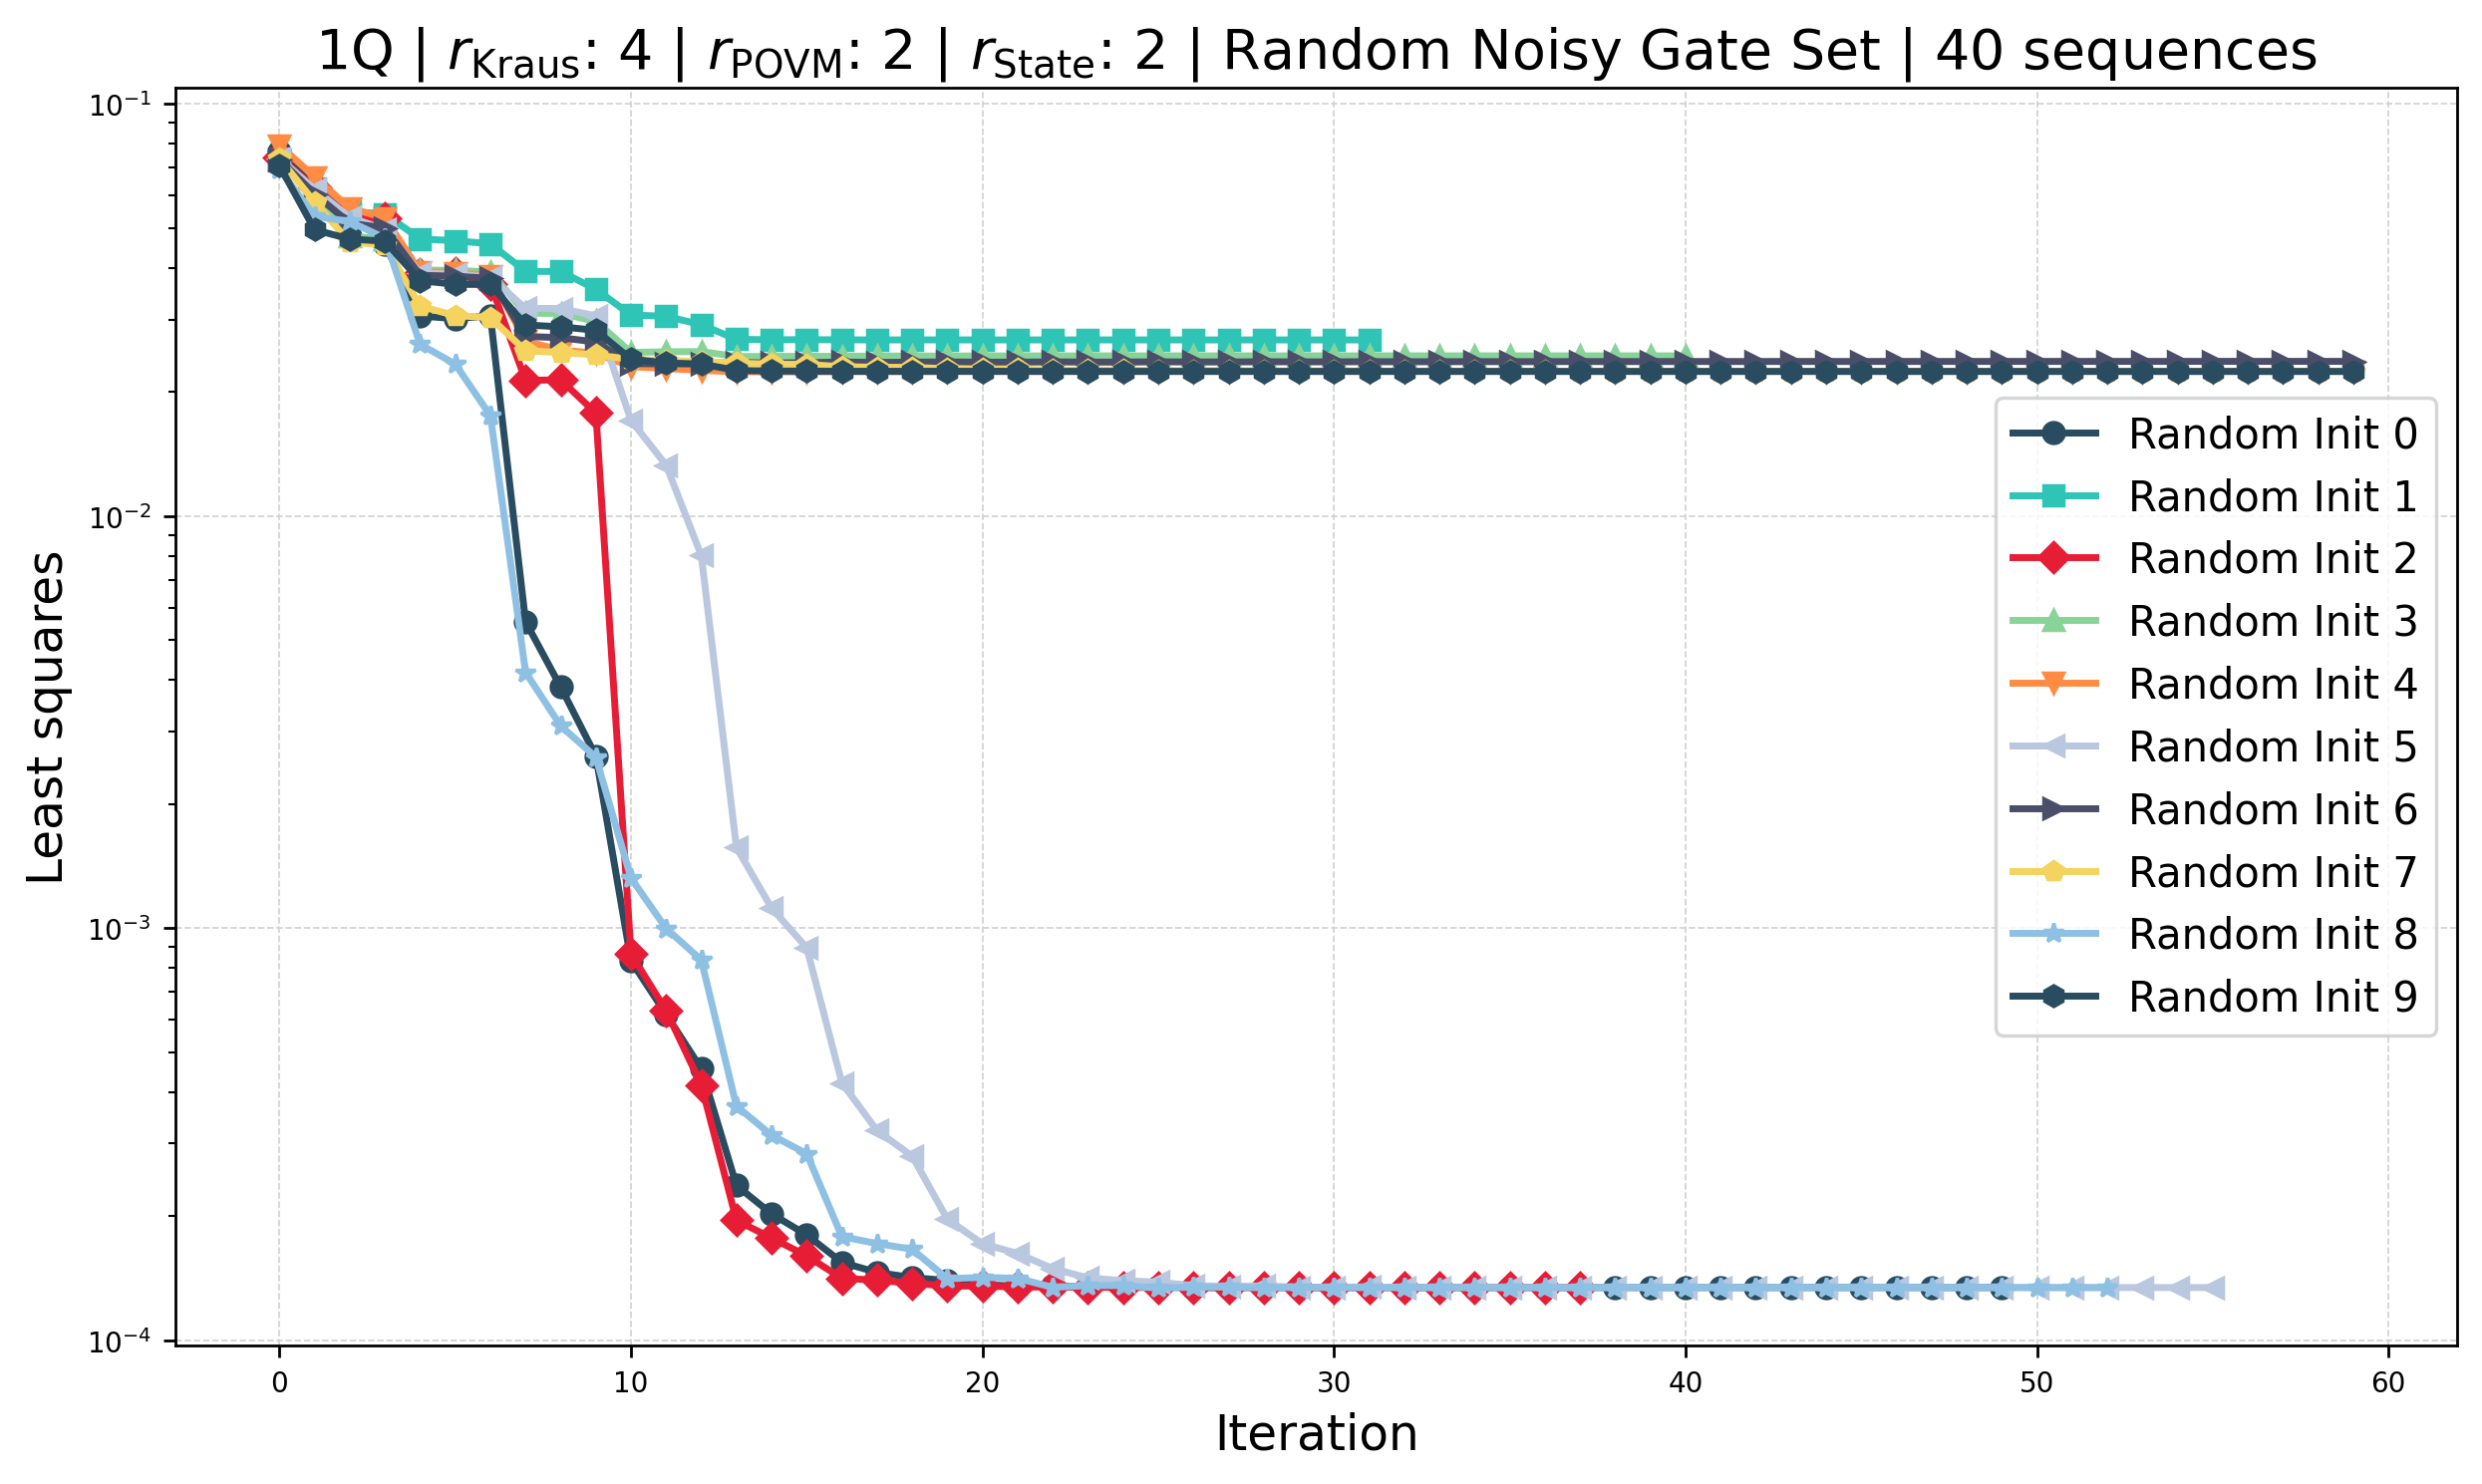

In [94]:
cost_fn_inits_40_seq = [res["cost_fn_history"]["least_squares"] for res in opt_results_random_inits_40_seq]

plot_cost_function(cost_fn_inits_40_seq[:], title=title_init + " | 40 sequences", labels=labels_init_small_seq[:], ylabel="Least squares")

# Random-multi init worfklow

## Tests

In [134]:
from mGST.simulate import compute_probability_matrices, batch_probability_matrices_and_indices

probability_matrices = compute_probability_matrices(*noisy_gate_set_psd.values(), gate_indices=indices_dict_fixed["gate_indices"], num_shots=num_shots, seed=42)

batch_size = 10

batched_probability_matrices, batched_indices_dict = batch_probability_matrices_and_indices(probability_matrices, indices_dict_fixed, 0.1, seed=None)

In [133]:
# estimate the noise threshold just to see if the optimizations above reached it
from mGST.trust_region import estimate_noise_floor_threshold

noise_threshold = estimate_noise_floor_threshold(multiplier=5.0, num_shots=num_shots, probability_matrix=probability_matrices["sampled"])
noise_threshold

Array(0.00091142, dtype=float64)

In [132]:
# get the minimum for every random initialization and for every number of sequences
cost_fns_vs_sequences = [cost_fn_inits_10_seq, cost_fn_inits_20_seq, cost_fn_inits_30_seq, cost_fn_inits_40_seq]
min_values_vs_sequences = [
    jnp.array([trajectory[-1] for trajectory in cost_fn_sequence]).min()
    for cost_fn_sequence in cost_fns_vs_sequences
]
print(min_values_vs_sequences)
all([min_value <= noise_threshold for min_value in min_values_vs_sequences])


[Array(6.88271679e-12, dtype=float64), Array(0.00010889, dtype=float64), Array(7.03574735e-05, dtype=float64), Array(0.00013424, dtype=float64)]


True

## Optimization

In [243]:
optimization_options_silence_new_version = optimization_options_silence.copy()
optimization_options_silence_new_version["compute_least_squares"] = True
optimization_options_silence_new_version["optimization_verbose"] = True

num_max_iterations_random_inits = 5
num_max_random_inits = 10
batch_size = 5
threshold_multiplier = 3.0

optimization_options_silence_new_version

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10,

In [146]:
probability_matrices_10_seq = compute_probability_matrices(*noisy_gate_set_psd.values(), gate_indices=indices_dict_10_seq["gate_indices"], num_shots=num_shots, seed=42)

In [188]:
final_result_10_seq, partial_result_10_seq = run_optimization_workflow_multi_init(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_silence_new_version,
    indices_dict=indices_dict_10_seq,
    probability_matrices=probability_matrices_10_seq,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=batch_size,
    threshold_multiplier=threshold_multiplier,
)

🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Noise Threshold 📶 6.00e-04 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
‼️ Full optimization finished at iteration 1/5 ‼️ 
 Reason: Cost function value for Povm below noise threshold 6.00e-04 📶.
✅ Converged below noise threshold after 1 random initializations.Inital cost function values: {'main': Array(4.91701995e-05, dtype=float64)}Last cost function values: {'main': Array(4.91701995e-05, dtype=float64)}
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-1

In [186]:
final_result_10_seq_v2, partial_result_10_seq_v2 = run_optimization_workflow_multi_init(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_silence_new_version,
    use_log_likelihood=True,
    indices_dict=indices_dict_10_seq,
    probability_matrices=probability_matrices_10_seq,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=batch_size,
    threshold_multiplier=threshold_multiplier,
)

🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Noise Threshold 📶 6.00e-04 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐

 🎯 [Povm] Relative change in cost function value: 0.00e+00. Target: 1.00e-11.

 🎯 [Kraus] Relative change in cost function value: 1.39e-03. Target: 1.00e-11.
‼️ Full optimization finished at iteration 1/5 ‼️ 
 Reason: Cost function value for State below noise threshold 6.00e-04 📶.
✅ Converged below noise threshold after 1 random initializations.Inital cost function values: {'main': Array(0.01917976, dtype=float64)}Last cost function values: {'main': Array(0.00012967, dtype=float64)}
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Opti

In [181]:
final_result_10_seq_v3, partial_result_10_seq_v3 = run_optimization_workflow_multi_init(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_silence_new_version,
    use_log_likelihood=True,
    indices_dict=indices_dict_10_seq,
    probability_matrices=probability_matrices_10_seq,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=batch_size,
    threshold_multiplier=threshold_multiplier,
)

🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Noise Threshold 📶 6.00e-04 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
👾 Least squares value after POVM: 5.824622e-02 👾

 🎯 [Povm] Relative change in cost function value: 0.00e+00. Target: 1.00e-11.
👾 Least squares value after Kraus: 2.080823e-02 👾

 🎯 [Kraus] Relative change in cost function value: 3.54e-02. Target: 1.00e-11.
👾 Least squares value after State at iteration 1: 9.616325e-03 👾
🏁 Iteration: 1/5. f(x): 9.616325e-03.

 🎯 [State] Relative change in cost function value: 4.60e-02. Target: 1.00e-11.
👾 Least squares value after POVM: 9.123993e-03 👾

 🎯 [Povm] Relative chang

In [184]:
final_result_10_seq_v3["cost_fn_history"].keys(), partial_result_10_seq_v3["cost_fn_history"].keys()

(dict_keys(['main', 'least_squares']), dict_keys(['main', 'least_squares']))

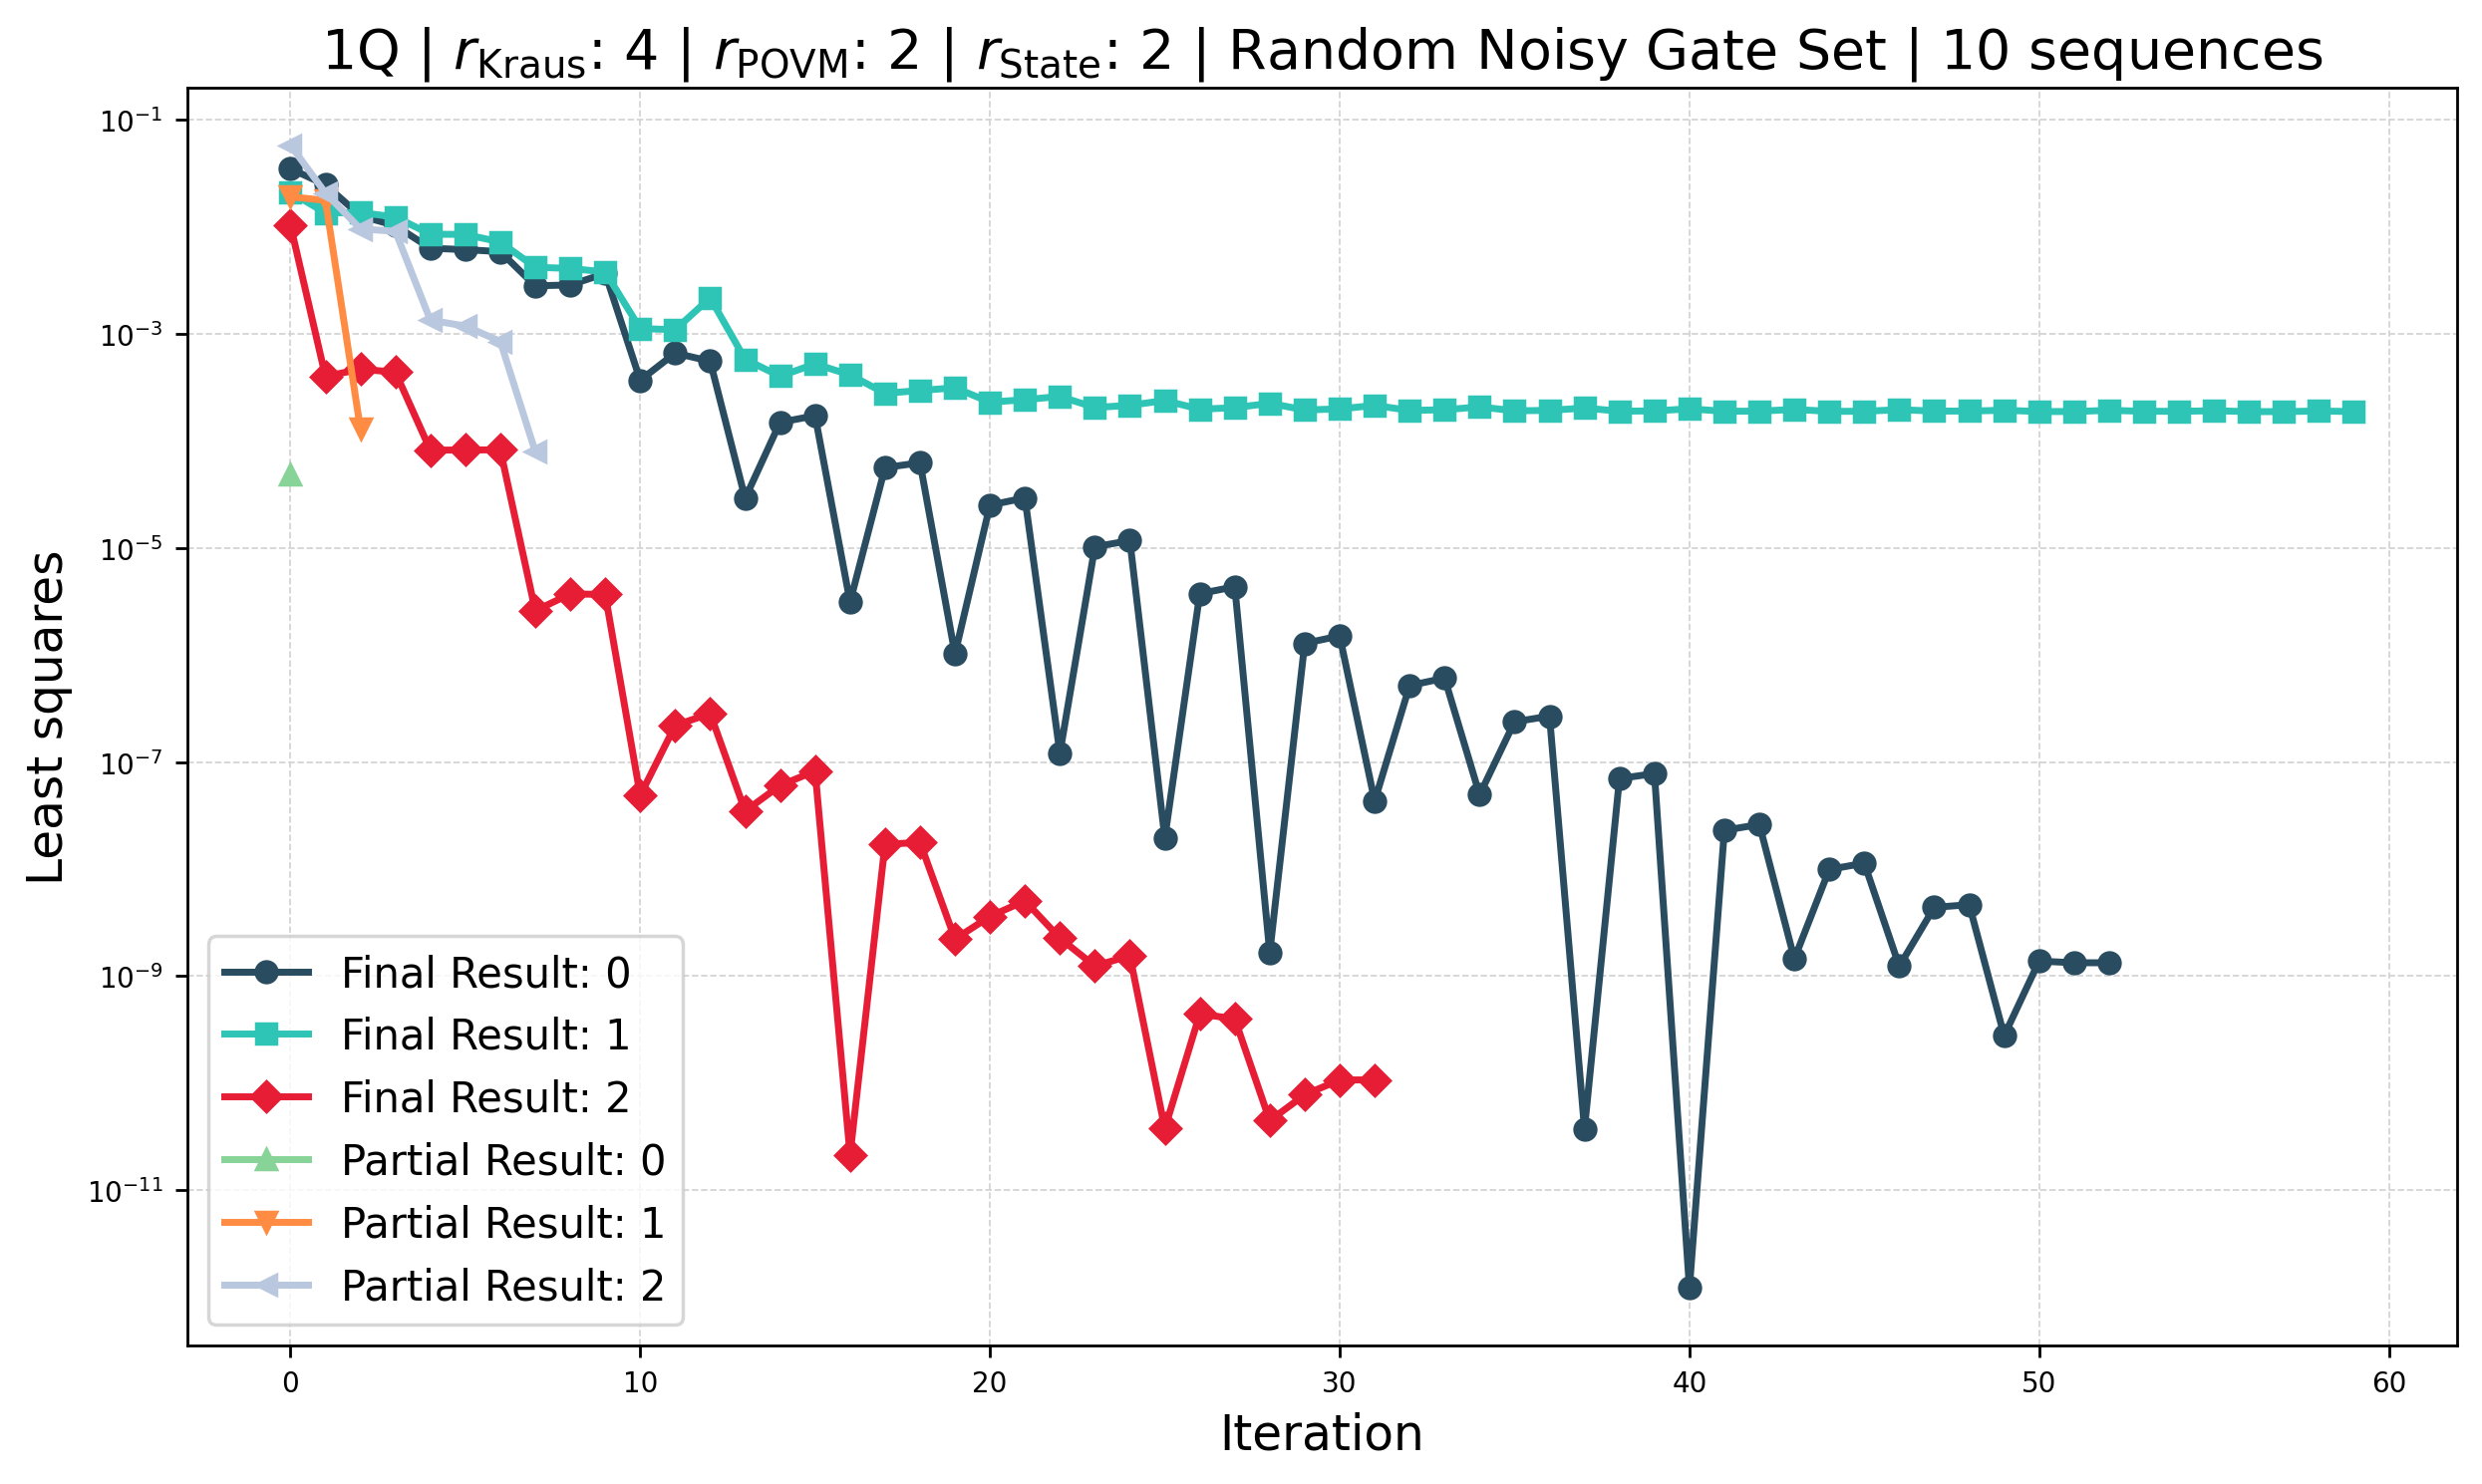

In [ ]:
partial_results = [partial_result_10_seq, partial_result_10_seq_v2, partial_result_10_seq_v3]
partial_costs = [res["cost_fn_history"]["main"] for res in partial_results]

final_results = [final_result_10_seq, final_result_10_seq_v2, final_result_10_seq_v3]
final_costs = [res["cost_fn_history"]["least_squares"] for res in final_results]

cost_fn_random_inits_10_seq = final_costs + partial_costs

labels_random_inits_10_seq = [f"Final Result: {i}" for i in range(len(final_results))] + [f"Partial Result: {i}" for i in range(len(partial_results))]

plot_cost_function(cost_fn_random_inits_10_seq[:], title=title_init + " | 10 sequences", labels=labels_random_inits_10_seq[:], ylabel="Least squares")

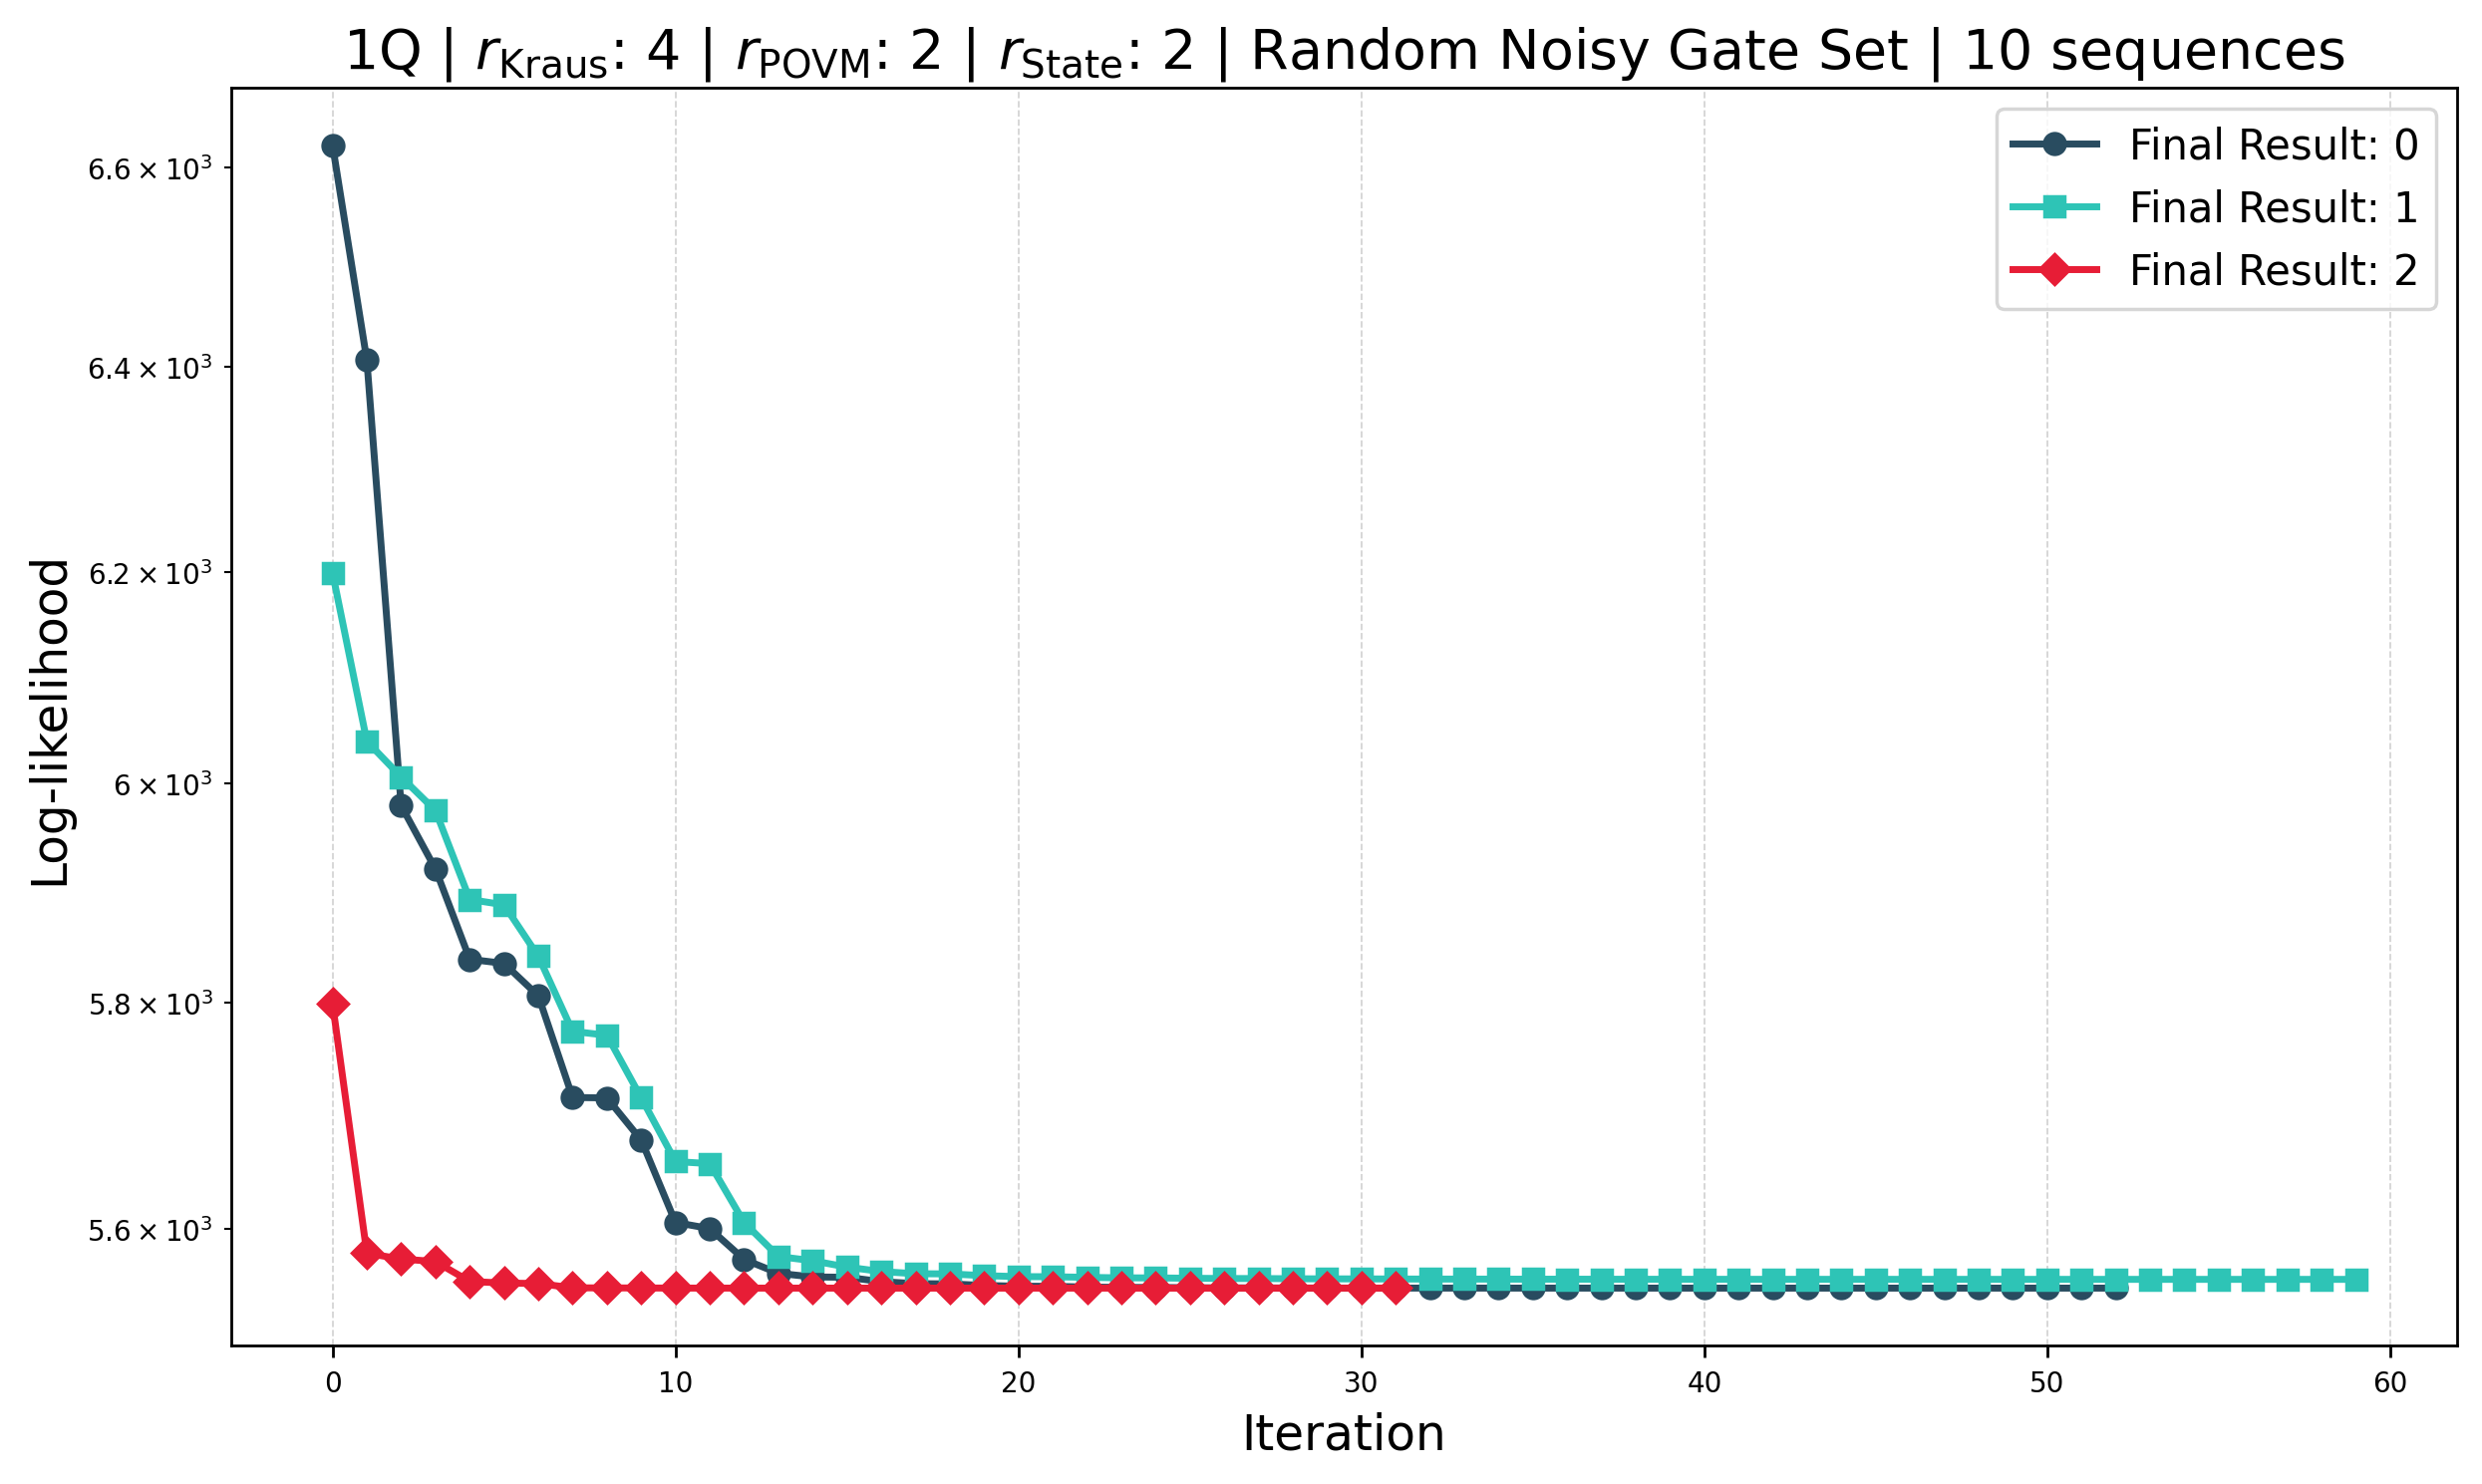

In [193]:
final_costs_log_likelihood = [res["cost_fn_history"]["main"] for res in final_results]

plot_cost_function(final_costs_log_likelihood[:], title=title_init + " | 10 sequences", labels=labels_random_inits_10_seq[:3], ylabel="Log-likelihood")

## MVE

In [214]:
opt_results_all_realizations = [[result] for result in final_results]
mve_seq_length = 10
num_circuits_sampled = int(1e3)
num_random_runs = 10

num_sequences = [10]

optimization_results_dict_10_seq = [
    {str(key): res for key, res in zip(num_sequences, realization_results)}
    for realization_results in opt_results_all_realizations
]
len(optimization_results_dict_10_seq), optimization_results_dict_10_seq[0].keys()

(3, dict_keys(['10']))

In [208]:
mve_10_seq, wve_10_seq = compute_mve_and_wve_for_all_realizations(
    optimization_results=optimization_results_dict_10_seq,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

In [211]:
mean_mve_10_seq= compute_avg_and_std_along_keys(list_of_errors=mve_10_seq)

{'10': {'mean': Array(0.29833131, dtype=float64),
  'std': Array(0.02999019, dtype=float64)}}

### Repeating in a structured way

In [244]:
batch_size_new = 0.5
num_realizations = 5
optimization_options_multi_realizations = optimization_options_silence_new_version.copy()
optimization_options_multi_realizations["optimization_verbose"] = False
optimization_options_multi_realizations

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10,

In [233]:
final_results_small, partial_results_small = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=[20, 30, 40],
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=batch_size_new,
    threshold_multiplier=threshold_multiplier,
    # seed=42,        # omit for fully random
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=20
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 2/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 3/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 4/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 5/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 4/5 ‼️ 
 Reas

In [245]:
optimization_options_multi_realizations

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10,

In [247]:
final_results_medium, partial_results_medium = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=[10, 50],
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=[5, 10],
    threshold_multiplier=threshold_multiplier,
    # seed=42,        # omit for fully random
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=10
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 2/5 ‼️ 
 Reason: Cost function value for Povm below noise threshold 5.24e-04 📶.
✅ Converged below noise threshold after 1 random initializations. 
 Initial cost function values: {'main': Array(0.04095212, dtype=float64)} 
 Last cost function values: {'main': Array(0.00051263, dtype=float64)}
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 15/20 ‼️ 
 Reason: Relative change in cost function value 0.00e+00 below target relative precision 1.00e-11 🎯.
  📊 num_sequences=50
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: Cost function value for Kraus below noise threshold 5.39e-04 📶.
✅ Converged below noise threshold after 1 random initializations. 
 Initial cos

In [257]:
final_results_large, partial_results_large = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=[60, 70],
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=[30, 40],
    threshold_multiplier=threshold_multiplier,
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=60
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 2/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 3/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 4/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 5/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reas

In [269]:
final_result_70_extra, partial_results_70_extra = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=[70],
    num_realizations=1,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=[40],
    threshold_multiplier=threshold_multiplier,
    debug=True,     # also captures partial results
)

🔁 Realization 1/1
  📊 num_sequences=70
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 2/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: Cost function value for Povm below noise threshold 4.39e-04 📶.
✅ Converged below noise threshold after 2 random initializations. 
 Initial cost function values: {'main': Array(0.07244975, dtype=float64)} 
 Last cost function values: {'main': Array(0.00041346, dtype=float64)}
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 17/20 ‼️ 
 Reason: Relative change in cost function value 5.91e-12 below target relative precision 1.00e-11 🎯.


In [300]:
final_results_large_large, partial_results_large_large = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=[80, 90],
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=[50, 60],
    threshold_multiplier=threshold_multiplier,
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=80
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 4/5 ‼️ 
 Reason: Cost function value for Kraus below noise threshold 4.50e-04 📶.
✅ Converged below noise threshold after 1 random initializations. 
 Initial cost function values: {'main': Array(0.05867823, dtype=float64)} 
 Last cost function values: {'main': Array(0.00042474, dtype=float64)}
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 13/20 ‼️ 
 Reason: Relative change in cost function value 5.37e-12 below target relative precision 1.00e-11 🎯.
  📊 num_sequences=90
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: No convergence criteria met yet ⏳.
🎲👾 Running optimization workflow with random initialization 2/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️

In [331]:
final_results_xl, partial_results_xl = run_optimization_workflow_multi_init_realizations(
    num_shots=num_shots,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    optimization_options=optimization_options_multi_realizations,
    num_sequences_list=[100],
    num_realizations=num_realizations,
    num_max_iterations_random_inits=num_max_iterations_random_inits,
    num_max_random_inits=num_max_random_inits,
    batch_size=[60],
    threshold_multiplier=threshold_multiplier,
    debug=True,     # also captures partial results
)

🔁 Realization 1/5
  📊 num_sequences=100
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: Cost function value for Kraus below noise threshold 5.17e-04 📶.
✅ Converged below noise threshold after 1 random initializations. 
 Initial cost function values: {'main': Array(0.06657817, dtype=float64)} 
 Last cost function values: {'main': Array(0.00033984, dtype=float64)}
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 14/20 ‼️ 
 Reason: Relative change in cost function value 8.65e-12 below target relative precision 1.00e-11 🎯.
🔁 Realization 2/5
  📊 num_sequences=100
🎲👾 Running optimization workflow with random initialization 1/10 🎲👾
🔰 Starting Riemannian Optimization 🔰
‼️ Full optimization finished at iteration 5/5 ‼️ 
 Reason: Cost function value for Kraus below noise threshold 4.87e-04 📶.
✅ Converged below noise threshold after 1 random initializ

In [332]:
# compute the MVE to see if the behaviour that we expected is observed
mve_results_small, wve_results_small = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_small,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

mve_results_medium, wve_results_medium = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_medium,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

mve_results_large, wve_results_large = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_large,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

mve_results_large_large, wve_results_large_large = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_large_large,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

mve_results_xl, wve_results_xl = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_results_xl,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)

In [333]:
mve_combined = combine_error_results(mve_results_small, mve_results_medium, mve_results_large, mve_results_large_large, mve_results_xl)
mean_mve_results_combined = compute_avg_and_std_along_keys(list_of_errors=mve_combined)

In [303]:
mve_results_large[1]["70"]

{'mean': Array(0.28618678, dtype=float64),
 'std': Array(0.00654866, dtype=float64)}

In [334]:
mve_added_70, wve_added_70 = compute_mve_and_wve_for_all_realizations(
    optimization_results=final_result_70_extra,
    true_superops=noisy_gate_set_superop,
    sequence_length=mve_seq_length,
    num_circuits_sampled=num_circuits_sampled,
    num_repetitions=num_random_runs,
    which_data="optimized_operators",
)
print(mve_added_70)

mve_combined_ammended = mve_combined.copy()
mve_combined_ammended[1]["70"] = mve_added_70[0]["70"]
mean_mve_results_combined_ammended = compute_avg_and_std_along_keys(list_of_errors=mve_combined_ammended)

[{'70': {'mean': Array(0.00393194, dtype=float64), 'std': Array(0.00016744, dtype=float64)}}]


### Visualization

In [321]:
import matplotlib.pyplot as plt

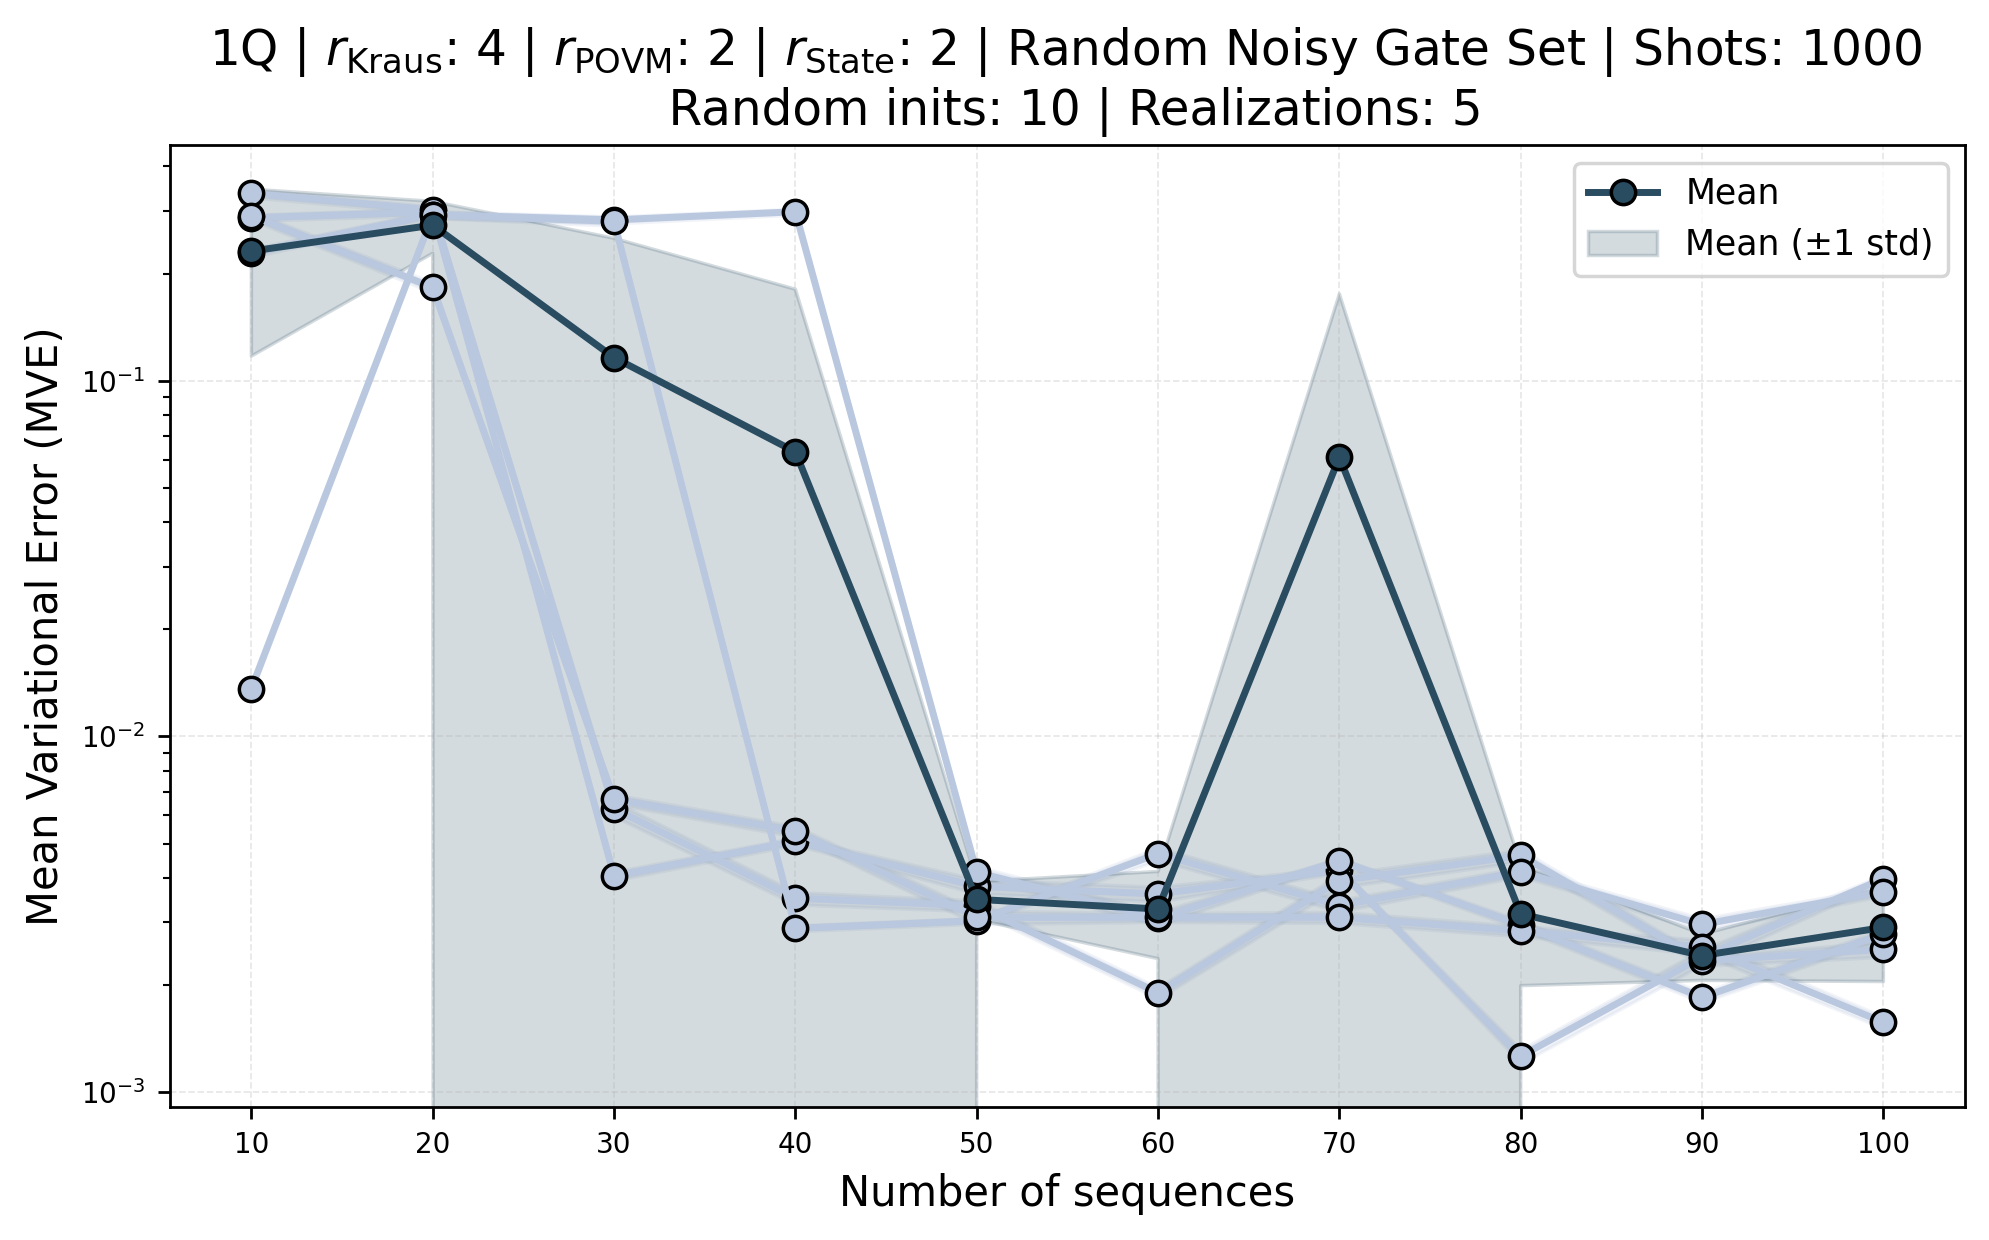

In [350]:
fig_all_mve = plot_many_mean_std_vs_x(
    data=mve_combined,
    title=title_init + f" \n Random inits: {num_max_random_inits} | Realizations: {num_realizations}",
    ylabel=f"Mean Variational Error (MVE)",
    use_log_scale="y",
    main_curve=mean_mve_results_combined,
    main_curve_label="Mean",
)

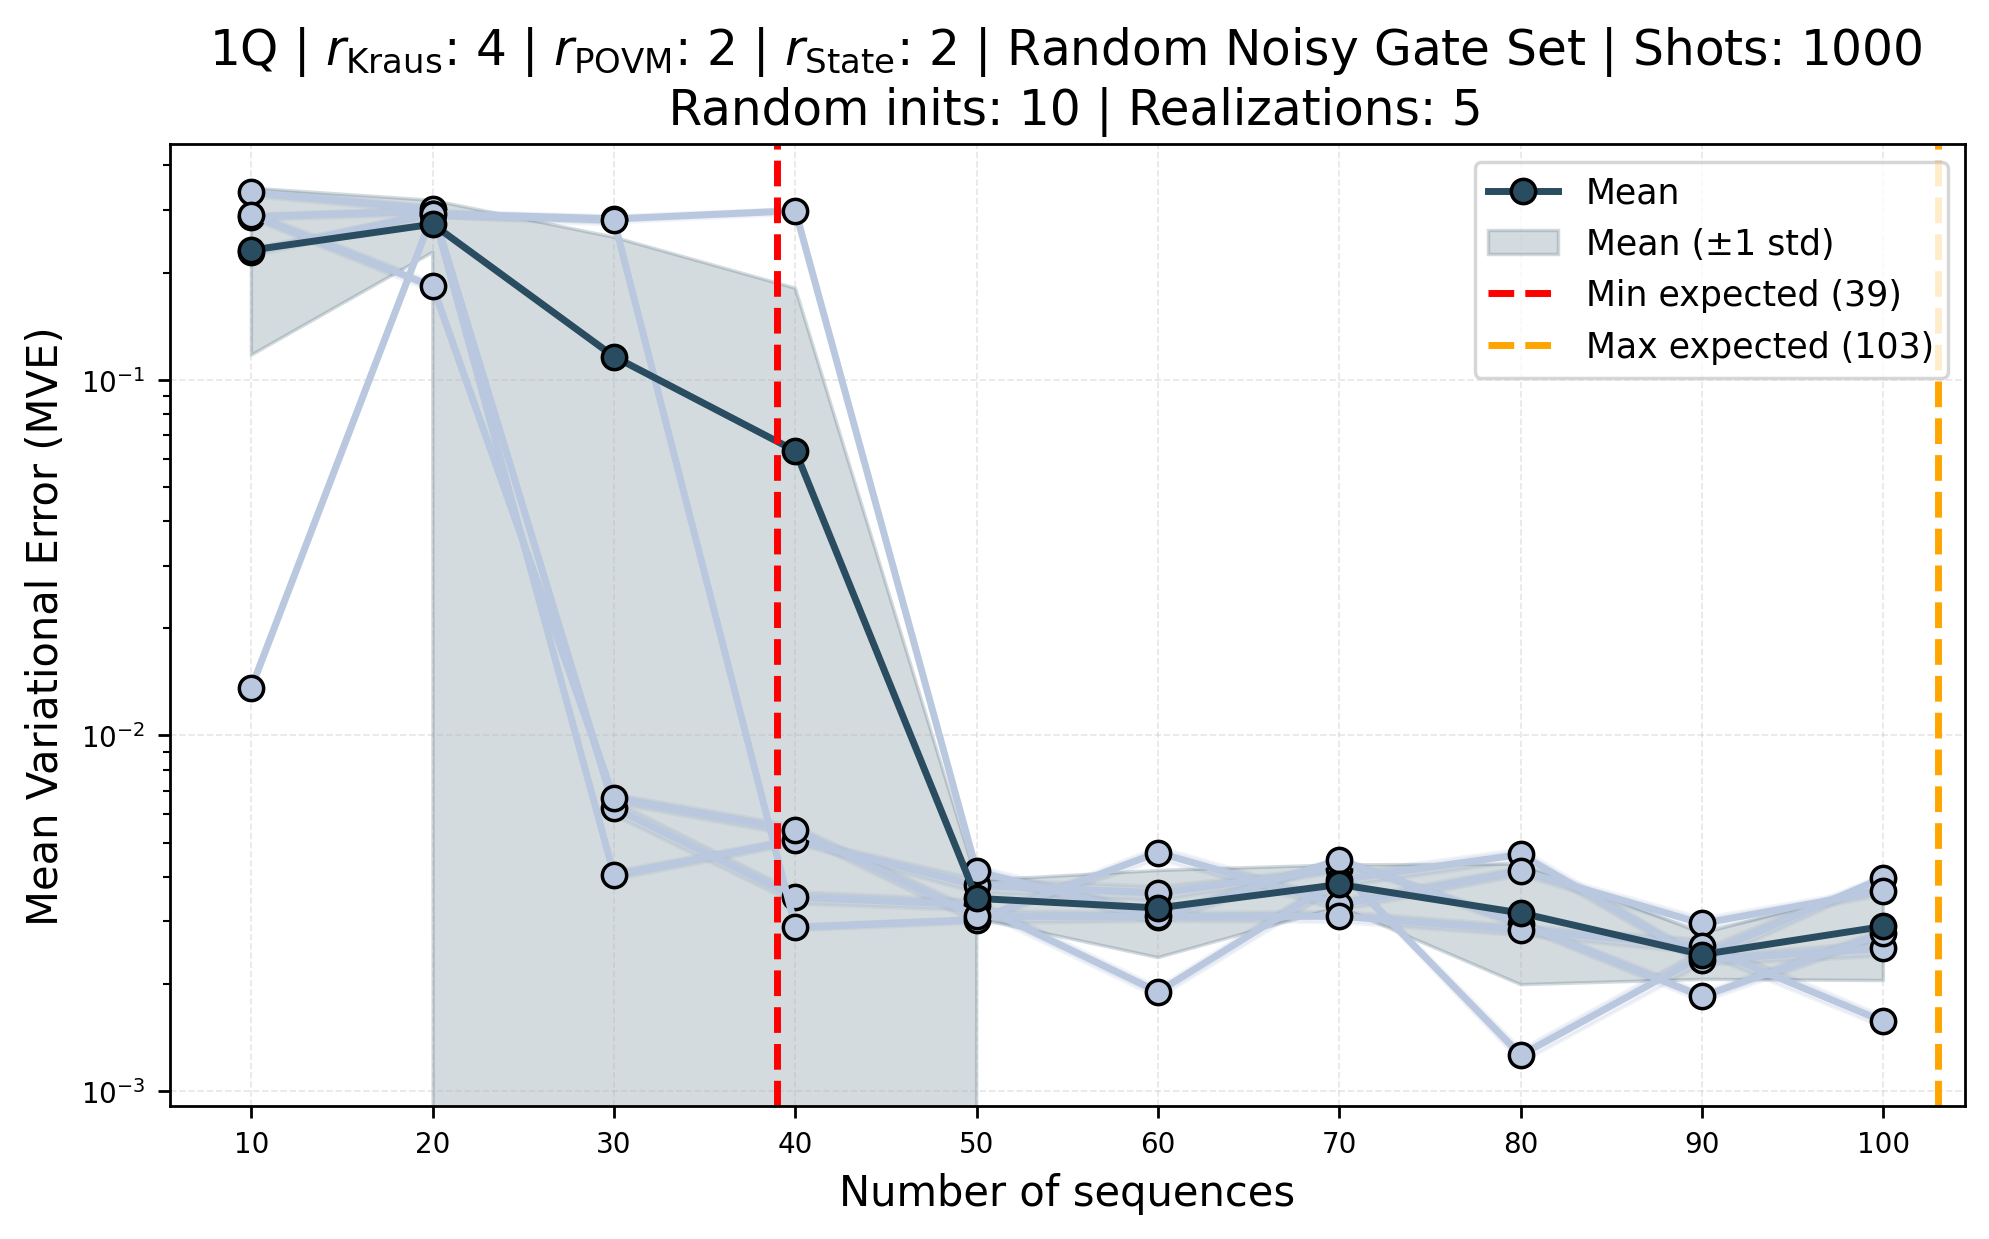

In [351]:
fig_all_mve_ammended = plot_many_mean_std_vs_x(
    data=mve_combined_ammended,
    title=title_init + f" \n Random inits: {num_max_random_inits} | Realizations: {num_realizations}",
    ylabel=f"Mean Variational Error (MVE)",
    use_log_scale="y",
    main_curve=mean_mve_results_combined_ammended,
    main_curve_label="Mean",
    show=False,
)

# Get the axes from the figure
ax = fig_all_mve_ammended.get_axes()[0]

# Add vertical lines for min and max expected sequences
line_min = ax.axvline(x=min_expected, color='red', linestyle='--', linewidth=2, label=f'Min expected ({min_expected})')
line_max = ax.axvline(x=max_expected, color='orange', linestyle='--', linewidth=2, label=f'Max expected ({max_expected})')

# Rebuild the legend to include the new lines
ax.legend(fontsize=10, loc='best')

# Refresh the layout and show
fig_all_mve_ammended.tight_layout()
plt.show()

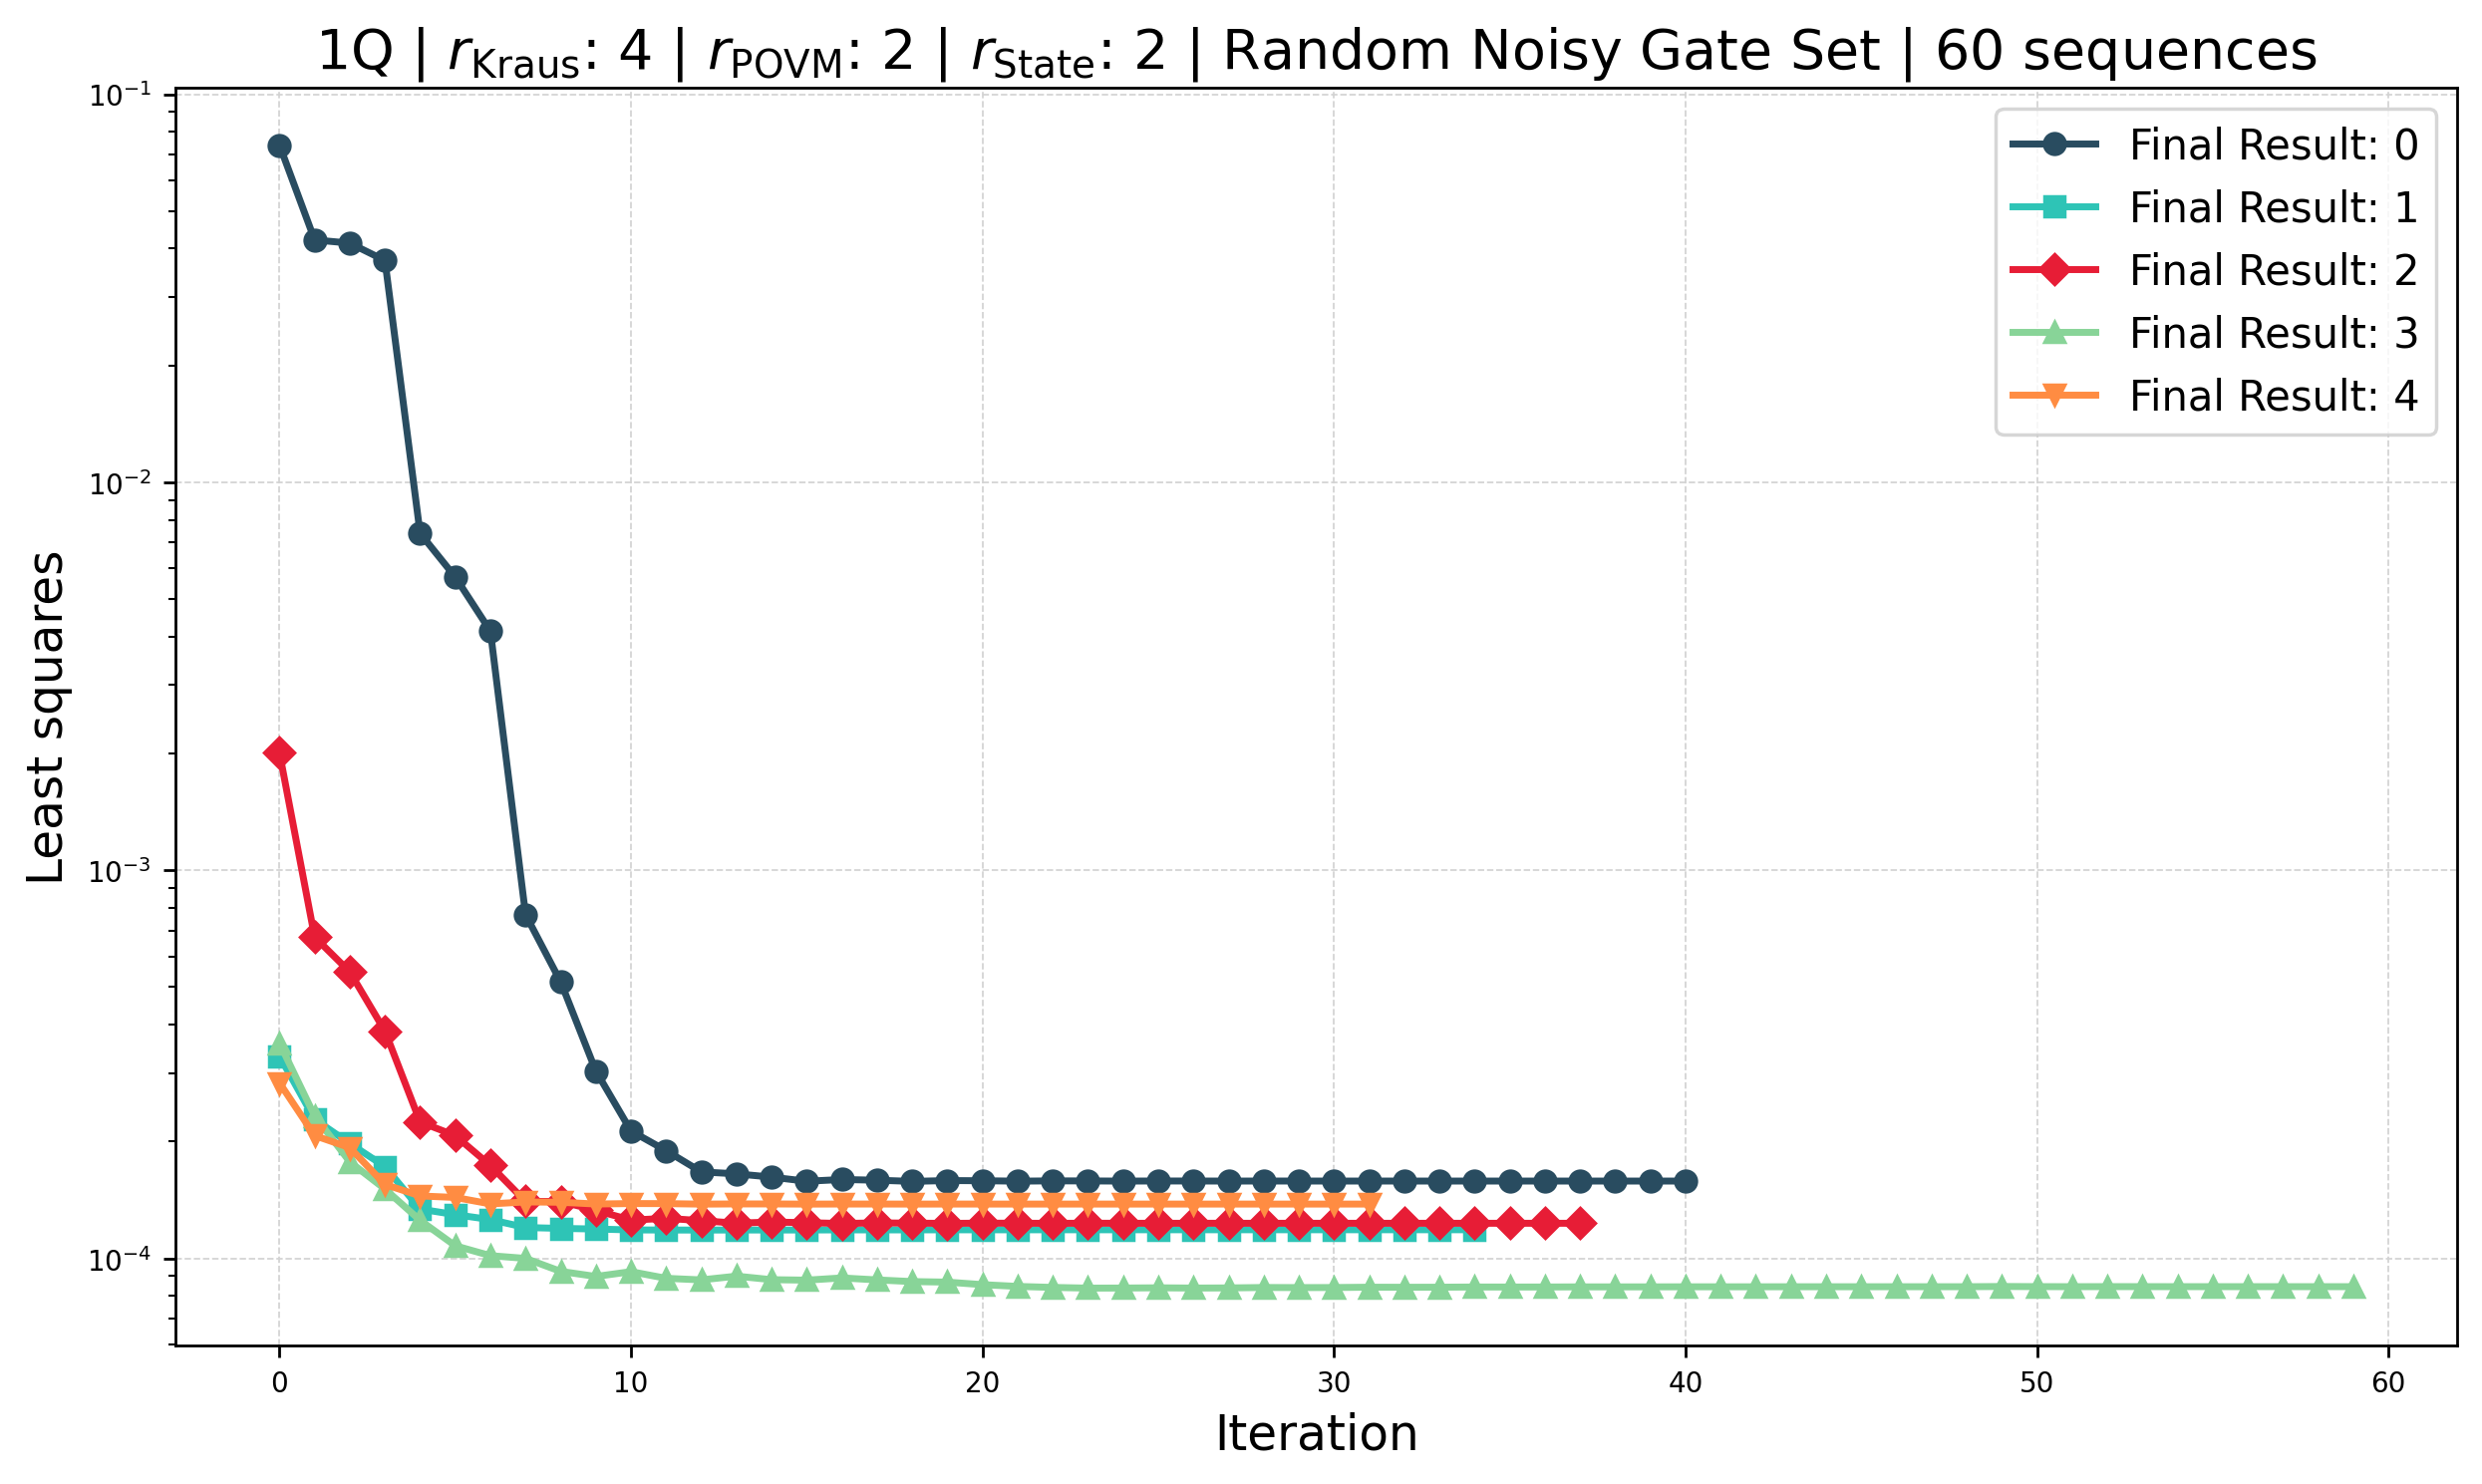

In [267]:
results_60_seq = get_all_realizations_for_key(final_results_large, "60")
costs_60_seq = [res["cost_fn_history"]["least_squares"] for res in results_60_seq]
labels_random_inits_60_seq = [f"Final Result: {i}" for i in range(len(results_60_seq))]
plot_cost_function(costs_60_seq[:], title=title_init + " | 60 sequences", labels=labels_random_inits_60_seq[:], ylabel="Least squares")

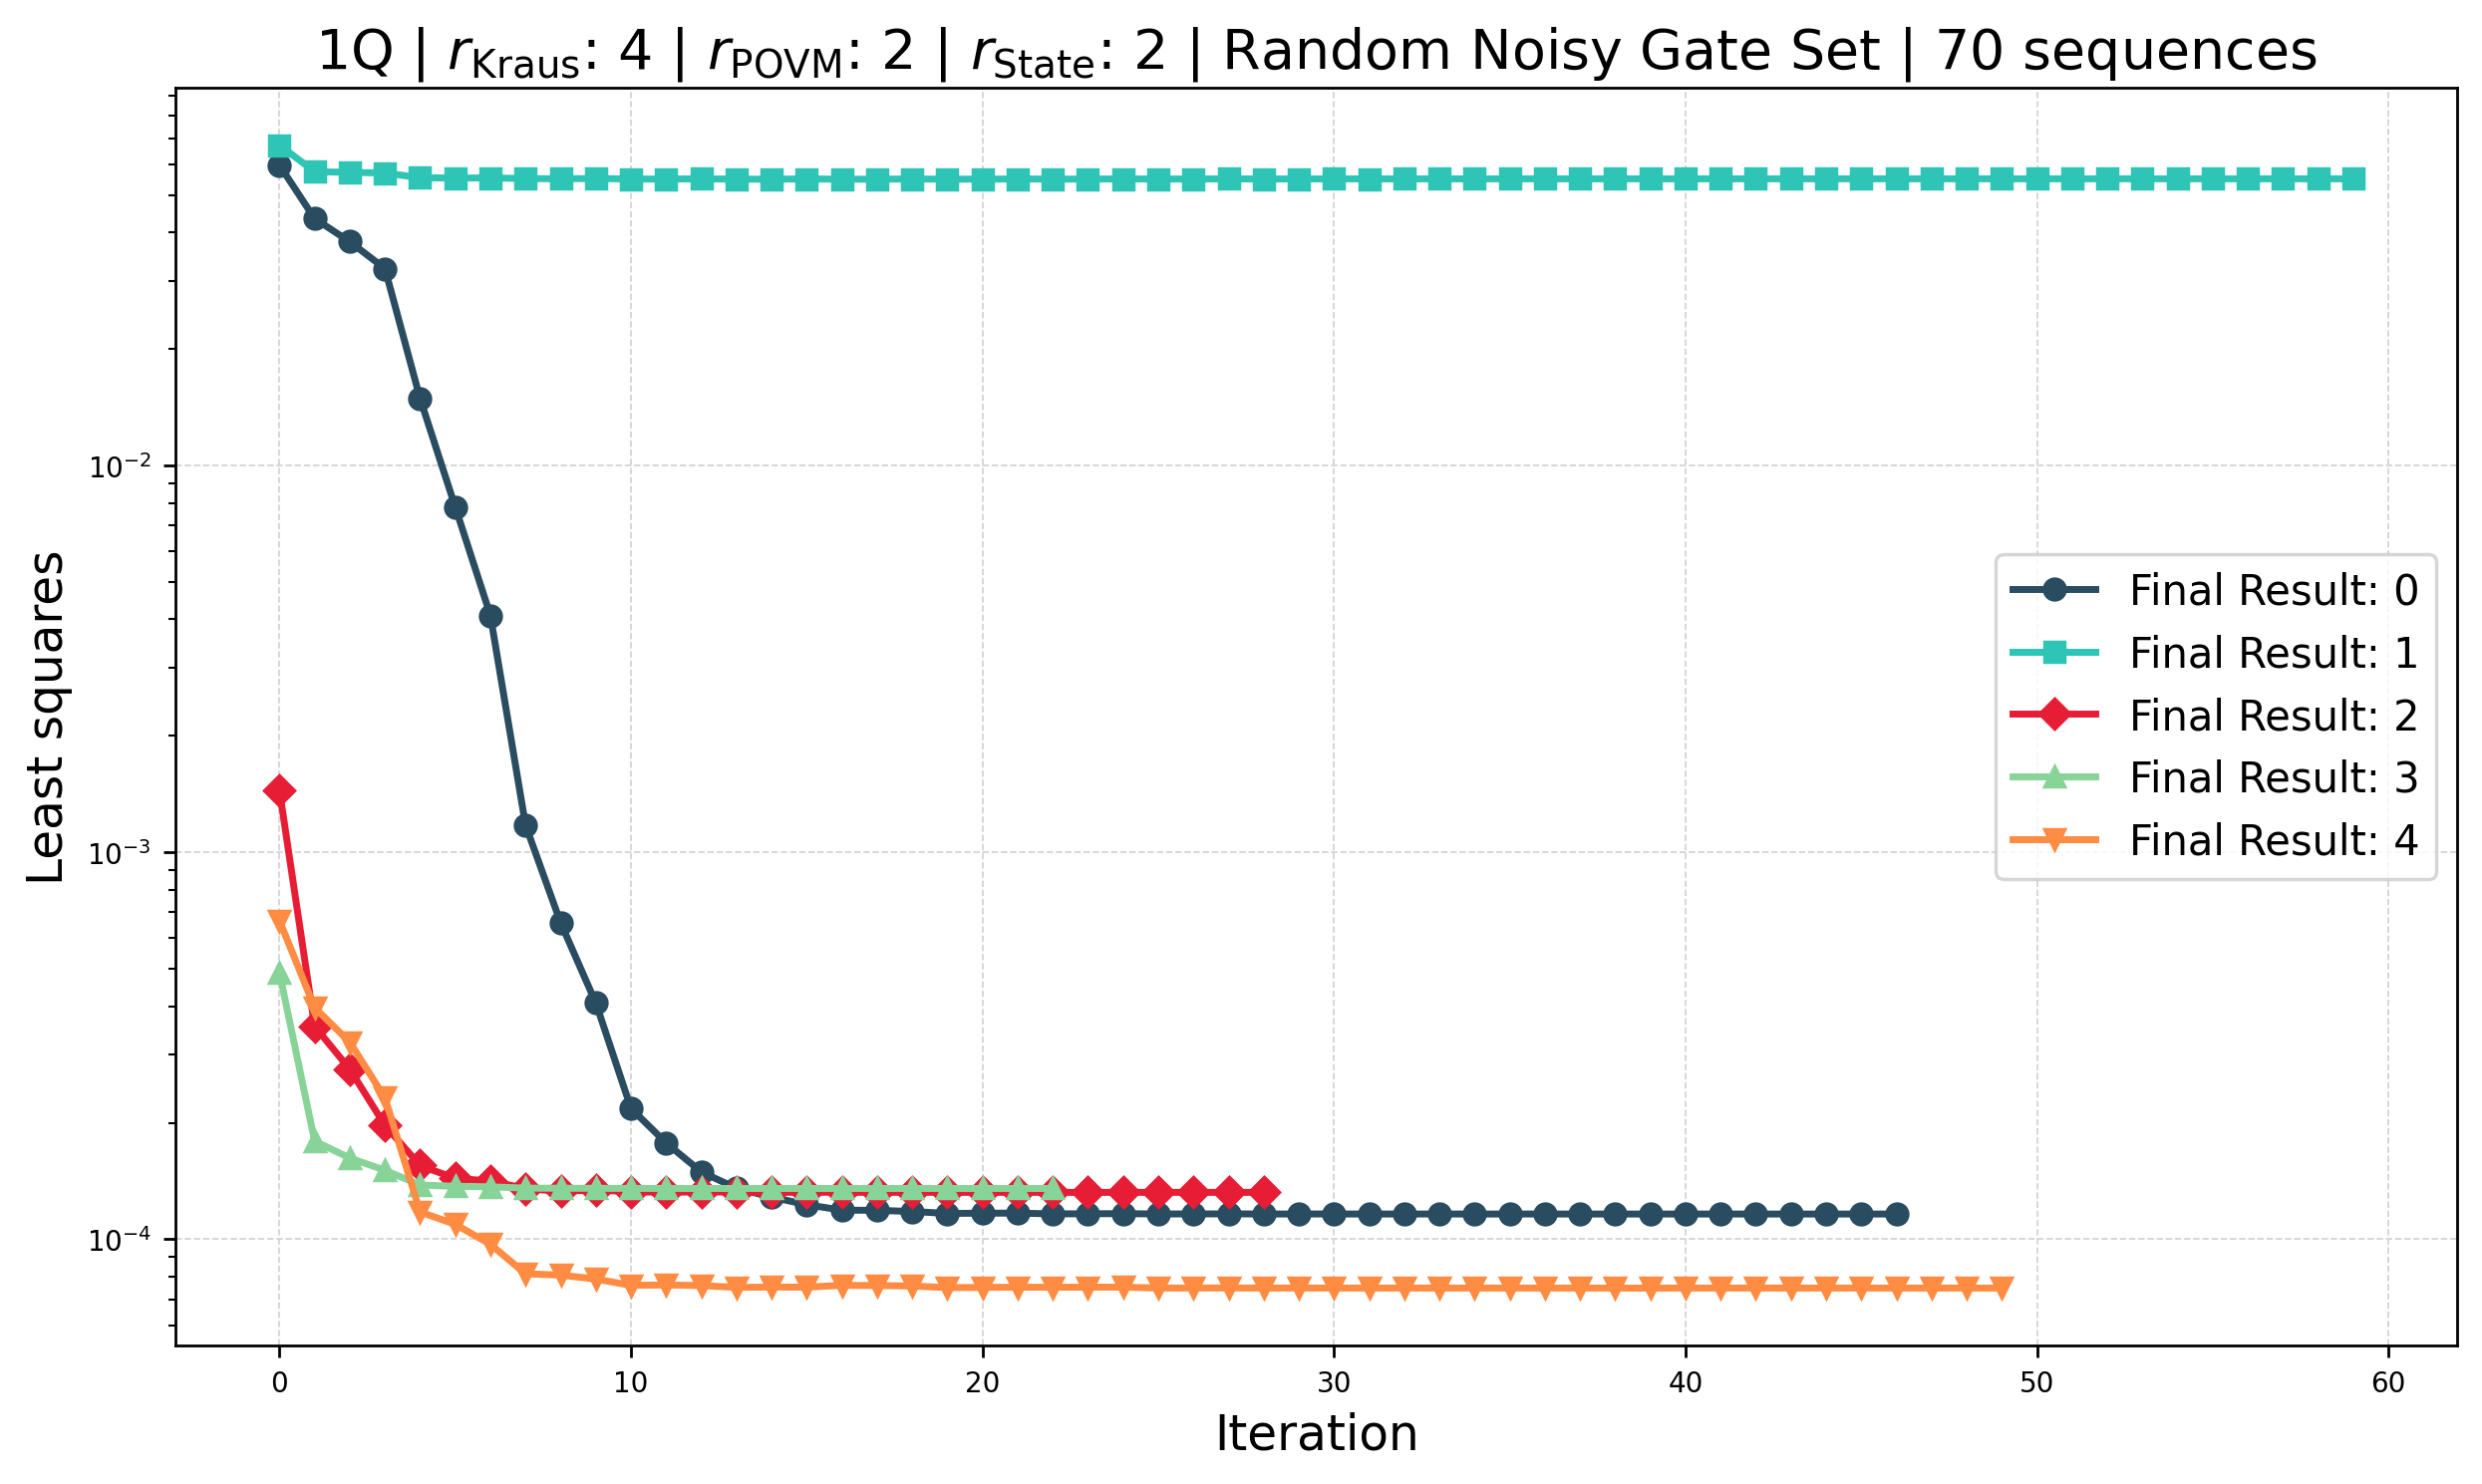

In [268]:
results_70_seq = get_all_realizations_for_key(final_results_large, "70")
costs_70_seq = [res["cost_fn_history"]["least_squares"] for res in results_70_seq]
labels_random_inits_70_seq = [f"Final Result: {i}" for i in range(len(results_70_seq))]
plot_cost_function(costs_70_seq[:], title=title_init + " | 70 sequences", labels=labels_random_inits_70_seq[:], ylabel="Least squares")

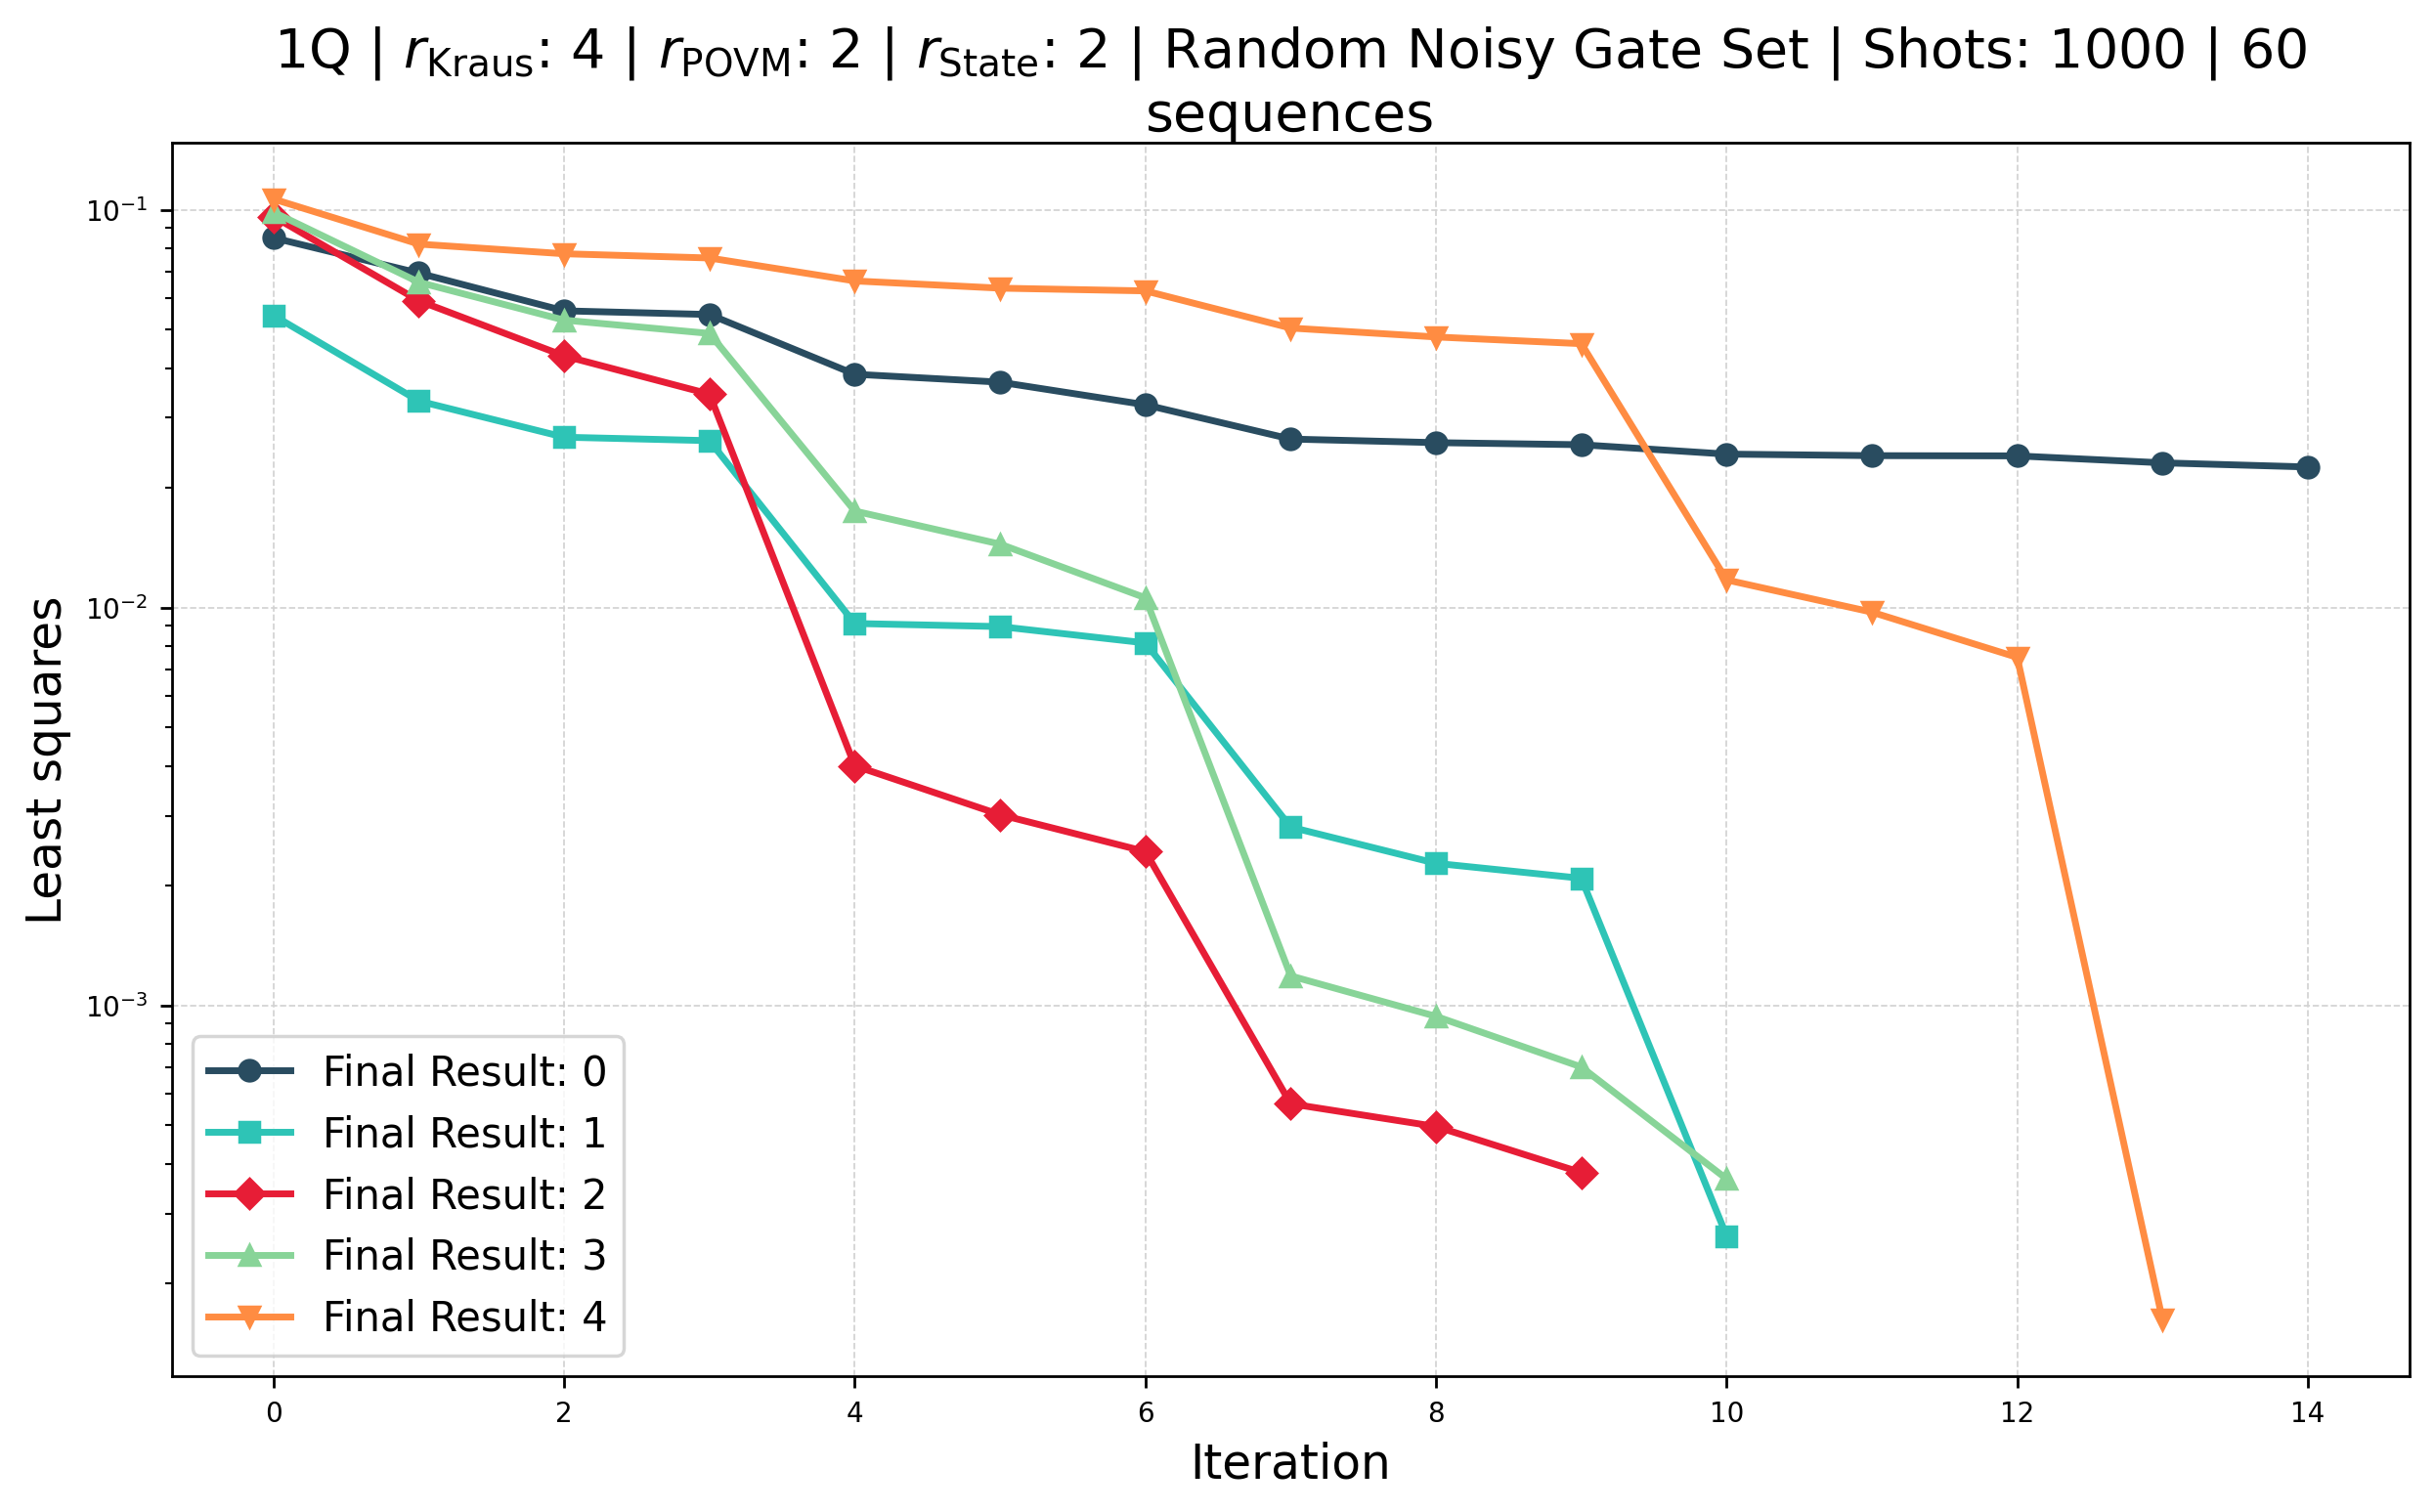

In [358]:
results_60_seq = get_all_realizations_for_key(partial_results_large, "60")
costs_60_seq = [res["cost_fn_history"]["main"] for res in results_60_seq]
labels_random_inits_60_seq = [f"Final Result: {i}" for i in range(len(results_60_seq))]
plot_cost_function(costs_60_seq[:], title=title_init + " | 60 sequences", labels=labels_random_inits_60_seq[:], ylabel="Least squares")

# Save data

In [347]:
folder = "data/random_init_vs_sequences"

save_optimization_result(final_results_small, f"{folder}/final_results_small.pkl")
save_optimization_result(final_results_medium, f"{folder}/final_results_medium.pkl")
save_optimization_result(final_results_large, f"{folder}/final_results_large.pkl")
save_optimization_result(final_results_large_large, f"{folder}/final_results_large_large.pkl")
save_optimization_result(final_results_xl, f"{folder}/final_results_xl.pkl")
save_optimization_result(final_result_70_extra, f"{folder}/final_result_70_extra.pkl")

Optimization result saved to data/random_init_vs_sequences/final_results_small.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_medium.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_large.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_large_large.pkl
Optimization result saved to data/random_init_vs_sequences/final_results_xl.pkl
Optimization result saved to data/random_init_vs_sequences/final_result_70_extra.pkl


In [348]:
save_variational_errors(error_results=mve_combined, filename=f"{folder}/mve_combined.json")
save_variational_errors(error_results=mve_combined_ammended, filename=f"{folder}/mve_combined_ammended.json")

Variational errors saved to data/random_init_vs_sequences/mve_combined.json
Variational errors saved to data/random_init_vs_sequences/mve_combined_ammended.json
